# Title: Sales forecatsing in Fashion Retail Industry using machine Learning

# Import relevant libraries and Dataset

In [ ]:
#  Importing relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
import warnings #ignore warning
warnings.filterwarnings("ignore")
from scipy import stats
from scipy.stats import skew, kurtosis
from statsmodels.tsa.stattools import kpss
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)


Mounted at /content/gdrive


In [ ]:
# Import Dataset
df_MenCNT_Sales2021 = pd.read_csv("/content/gdrive/MyDrive/dataset/Men _CNT_2021_Sales.csv",index_col=[0])
df_MenCNT_Sales2022 = pd.read_csv("/content/gdrive/MyDrive/dataset/Men CNT_2022_Sales.csv",index_col=[0])

df_MenCNT_Traffic2021 = pd.read_csv("/content/gdrive/MyDrive/dataset/Men_CNT_2021_Traffic.csv",index_col=[0])
df_MenCNT_Traffic2022 = pd.read_csv("/content/gdrive/MyDrive/dataset/Men_CNT_2022_Traffic.csv",index_col=[0])

df_FB_OxwhiteMY2021 = pd.read_csv("/content/gdrive/MyDrive/dataset/FB_OxwhiteMY_2021_CNT.csv",index_col=[0], parse_dates=[0])
df_FB_OxwhiteMY2022 = pd.read_csv("/content/gdrive/MyDrive/dataset/FB_OxwhiteMY_2022_CNT.csv",index_col=[0], parse_dates=[0])

df_MenCNT_AOV2021_2022 = pd.read_csv("/content/gdrive/MyDrive/dataset/AOV_ Men_CNT.csv", index_col=[0], parse_dates=[0])
df_MenCNT_CR_BR2021_2022 = pd.read_csv("/content/gdrive/MyDrive/dataset/CR_Bounce Rate_Men_CNT.csv",index_col=[0])

# Combine datasets into 1 dataframe
### We got 8 dataset. Below is the columns and rows in these dataset.we need to combine them into 1 dataset. Print the info for all datasets
#### Men CNT 2021Sales

In [ ]:
print(df_MenCNT_Sales2021.info())

<class 'pandas.core.frame.DataFrame'>
Index: 6191 entries, Men Premium Weight Cotton Crew Neck Tee to Men Premium Weight Cotton Crew Neck Tee
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_vendor  6191 non-null   object 
 1   product_type    6191 non-null   object 
 2   hour            6191 non-null   object 
 3   net_quantity    6191 non-null   int64  
 4   gross_sales     6191 non-null   float64
 5   discounts       6191 non-null   float64
 6   returns         6191 non-null   float64
 7   net_sales       6191 non-null   float64
 8   taxes           6191 non-null   float64
 9   total_sales     6191 non-null   float64
dtypes: float64(6), int64(1), object(3)
memory usage: 532.0+ KB
None


#### Men CNT 2022 Sales

In [ ]:
print(df_MenCNT_Sales2022.info())

<class 'pandas.core.frame.DataFrame'>
Index: 7023 entries, Men Premium Weight Cotton Crew Neck Tee to Men Premium Weight Cotton Crew Neck Tee (Seasonal)
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_vendor  7023 non-null   object 
 1   product_type    7023 non-null   object 
 2   hour            7023 non-null   object 
 3   net_quantity    7023 non-null   int64  
 4   gross_sales     7023 non-null   float64
 5   discounts       7023 non-null   float64
 6   returns         7023 non-null   float64
 7   net_sales       7023 non-null   float64
 8   taxes           7023 non-null   float64
 9   total_sales     7023 non-null   float64
dtypes: float64(6), int64(1), object(3)
memory usage: 603.5+ KB
None


#### Men CNT 2021Traffic

In [ ]:
print(df_MenCNT_Traffic2021.info())

<class 'pandas.core.frame.DataFrame'>
Index: 31046 entries, Product to Product
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   page_path            31046 non-null  object 
 1   ua_form_factor       31046 non-null  object 
 2   referrer_source      31046 non-null  object 
 3   referrer_name        18022 non-null  object 
 4   hour                 31046 non-null  object 
 5   total_visitors       31046 non-null  int64  
 6   total_sessions       31046 non-null  int64  
 7   total_carts          31046 non-null  int64  
 8   total_checkouts      31046 non-null  int64  
 9   avg_duration         31046 non-null  object 
 10  total_bounce_rate    31046 non-null  float64
 11  total_conversion     31046 non-null  float64
 12  total_orders_placed  31046 non-null  int64  
 13  total_pageviews      31046 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 3.6+ MB
None


#### Men CNT 2022Traffic

In [ ]:
print(df_MenCNT_Traffic2022.info())

<class 'pandas.core.frame.DataFrame'>
Index: 29361 entries, Product to Product
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   page_path            29361 non-null  object 
 1   ua_form_factor       29361 non-null  object 
 2   referrer_source      29361 non-null  object 
 3   referrer_name        14548 non-null  object 
 4   hour                 29361 non-null  object 
 5   total_visitors       29361 non-null  int64  
 6   total_sessions       29361 non-null  int64  
 7   total_carts          29361 non-null  int64  
 8   total_checkouts      29361 non-null  int64  
 9   avg_duration         29361 non-null  object 
 10  total_bounce_rate    29361 non-null  float64
 11  total_conversion     29361 non-null  float64
 12  total_orders_placed  29361 non-null  int64  
 13  total_pageviews      29361 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 3.4+ MB
None


#### FB-OxwhiteMY-2021-CNT

In [ ]:
print(df_FB_OxwhiteMY2021.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 14965 entries, 2021-12-31 to 2021-01-01
Data columns (total 23 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Reporting ends                              14965 non-null  object 
 1   Campaign name                               14965 non-null  object 
 2   Attribution setting                         14965 non-null  object 
 3   Results                                     1361 non-null   float64
 4   Result indicator                            1361 non-null   object 
 5   Reach                                       14965 non-null  int64  
 6   Impressions                                 14965 non-null  int64  
 7   Cost per results                            1361 non-null   float64
 8   Amount spent (MYR)                          14965 non-null  float64
 9   Purchases conversion value                  1228 non-null   float6

#### FB-OxwhiteMY-2022-CNT

In [ ]:
print(df_FB_OxwhiteMY2022.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 30660 entries, 2022-12-31 to 2022-01-01
Data columns (total 23 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Reporting ends                              30660 non-null  object 
 1   Campaign name                               30660 non-null  object 
 2   Attribution setting                         30660 non-null  object 
 3   Results                                     551 non-null    float64
 4   Result indicator                            551 non-null    object 
 5   Reach                                       30660 non-null  int64  
 6   Impressions                                 30660 non-null  int64  
 7   Cost per results                            551 non-null    float64
 8   Amount spent (MYR)                          30660 non-null  float64
 9   Purchases conversion value                  732 non-null    float6

#### AOV Men CNT

In [ ]:
print(df_MenCNT_AOV2021_2022.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 806 entries, 2021-01-01 to 2022-12-31
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_title        806 non-null    object 
 1   average_order_value  806 non-null    float64
dtypes: float64(1), object(1)
memory usage: 18.9+ KB
None


## CR & Bounce Rate - Men CNT

In [ ]:
print(df_MenCNT_CR_BR2021_2022.info())

<class 'pandas.core.frame.DataFrame'>
Index: 813 entries, /products/men-premium-weight-cotton-crew-neck-tee to /products/men-premium-weight-cotton-crew-neck-tee-seasonal
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   day                813 non-null    object 
 1   total_conversion   813 non-null    float64
 2   total_bounce_rate  813 non-null    float64
dtypes: float64(2), object(1)
memory usage: 25.4+ KB
None


#### Combine MenCNT sales 2021 with MenCNT sales 2022

In [ ]:
df_MenCNT_Sales2021_2022 = pd.concat([df_MenCNT_Sales2021, df_MenCNT_Sales2022])
df_MenCNT_Sales2021_2022 = df_MenCNT_Sales2021_2022.reset_index()

#change the type of hour to datetime
df_MenCNT_Sales2021_2022['hour'] = pd.to_datetime(df_MenCNT_Sales2021_2022['hour'])
df_MenCNT_Sales2021_2022 = df_MenCNT_Sales2021_2022[['product_title','hour','discounts','total_sales']]

#change the type of product_title(object) to category
df_MenCNT_Sales2021_2022['product_title'] = df_MenCNT_Sales2021_2022['product_title'].astype('category')
unique_product_titles = df_MenCNT_Sales2021_2022['product_title'].unique()

#change the type of price columns into integer
price_cols = ['discounts','total_sales']
df_MenCNT_Sales2021_2022[price_cols] = df_MenCNT_Sales2021_2022[price_cols].astype('int')

df_MenCNT_Sales2021_2022.tail(5)

,product_title,hour,discounts,total_sales
13209,Men Premium Weight Cotton Crew Neck Tee (Essen...,2022-12-31 21:00:00,-31,124
13210,Men Premium Weight Cotton Crew Neck Tee (Seaso...,2022-12-31 22:00:00,-62,366
13211,Men Premium Weight Cotton Crew Neck Tee (Essen...,2022-12-31 22:00:00,-10,29
13212,Men Premium Weight Cotton Crew Neck Tee (Essen...,2022-12-31 23:00:00,-15,62
13213,Men Premium Weight Cotton Crew Neck Tee (Seaso...,2022-12-31 23:00:00,-93,374


#### Combine MenCNT traffic 2021 with MenCNT traffic 2022

In [ ]:
df_MenCNT_Traffic2021_2022 = pd.concat([df_MenCNT_Traffic2021,df_MenCNT_Traffic2022])
df_MenCNT_Traffic2021_2022 = df_MenCNT_Traffic2021_2022.reset_index()

#change the type of hour to datetime
df_MenCNT_Traffic2021_2022['hour'] = pd.to_datetime(df_MenCNT_Traffic2021_2022['hour'])
df_MenCNT_Traffic2021_2022 = df_MenCNT_Traffic2021_2022[['page_path','ua_form_factor','referrer_source','hour','total_visitors','total_checkouts','total_pageviews']]

#change page_path(object) to category
df_MenCNT_Traffic2021_2022['page_path'] = df_MenCNT_Traffic2021_2022['page_path'].astype('category')
df_MenCNT_Traffic2021_2022['ua_form_factor'] = df_MenCNT_Traffic2021_2022['ua_form_factor'].astype('category')
df_MenCNT_Traffic2021_2022['referrer_source'] = df_MenCNT_Traffic2021_2022['referrer_source'].astype('category')
unique_product_path = df_MenCNT_Traffic2021_2022['page_path'].unique()
df_MenCNT_Traffic2021_2022.tail(5)



,page_path,ua_form_factor,referrer_source,hour,total_visitors,total_checkouts,total_pageviews
60402,/products/men-premium-weight-cotton-crew-neck-...,Desktop,Direct,2022-12-31 23:00:00,1,0,12
60403,/products/men-premium-weight-cotton-crew-neck-...,Mobile,Direct,2022-12-31 23:00:00,2,0,2
60404,/products/men-premium-weight-cotton-crew-neck-...,Mobile,Social,2022-12-31 23:00:00,4,0,4
60405,/products/men-premium-weight-cotton-crew-neck-...,Desktop,Direct,2022-12-31 23:00:00,3,1,56
60406,/products/men-premium-weight-cotton-crew-neck-...,Mobile,Direct,2022-12-31 23:00:00,4,0,9


#### Combine FB Oxwhite2021 with FB Oxwhite 2022

In [ ]:
df_FB_OxwhiteMY2021_2022 = pd.concat([df_FB_OxwhiteMY2021,df_FB_OxwhiteMY2022])
df_FB_OxwhiteMY2021_2022 = df_FB_OxwhiteMY2021_2022.reset_index()
df_FB_OxwhiteMY2021_2022.columns = df_FB_OxwhiteMY2021_2022.columns.str.replace('\s+', '_')
df_FB_OxwhiteMY2021_2022['Reporting_starts'] = pd.to_datetime(df_FB_OxwhiteMY2021_2022['Reporting_starts'])

#calculate the the FB conversion Rate by result and outbound click
df_FB_OxwhiteMY2021_2022['FB_Conversion_Rate'] = df_FB_OxwhiteMY2021_2022['Results']/df_FB_OxwhiteMY2021_2022['Outbound_clicks']
df_FB_OxwhiteMY2021_2022 = df_FB_OxwhiteMY2021_2022[['Reporting_starts','Campaign_name','FB_Conversion_Rate','Cost_per_results','Website_purchase_ROAS_(return_on_ad_spend)','CTR_(all)']]
df_FB_OxwhiteMY2021_2022 = df_FB_OxwhiteMY2021_2022.rename(columns={'Reporting_starts': 'Date', 'FB_Conversion_Rate': 'FB_Conversion_Rate',
                                                                    'Cost_per_results': 'FB_CPA', 'Website_purchase_ROAS_(return_on_ad_spend)': 'FB_ROAS', 'CTR_(all)': 'FB_CTR'})
df_FB_OxwhiteMY2021_2022.tail(5)

,Date,Campaign_name,FB_Conversion_Rate,FB_CPA,FB_ROAS,FB_CTR
45620,2022-01-01,Z21 STUDIO | 0 | WC | (Women) - Crew Neck Tee ...,NaN,NaN,NaN,0.0
45621,2022-01-01,☑️ Z21 STUDIO | 0 | WC | (Men) - CNY Crew Neck...,NaN,NaN,NaN,0.0
45622,2022-01-01,Z21 STUDIO | 1 | COLD | WC | MY (Men) - TEST -...,NaN,NaN,NaN,0.0
45623,2022-01-01,Z21 STUDIO | 2 + 3 | BAU | Women Premium Weigh...,NaN,NaN,NaN,0.0
45624,2022-01-01,Z21 STUDIO | 0 | WC | (Men) - Crew Neck Tee (H...,NaN,NaN,NaN,0.0


### Format AOV_2021_2022

In [ ]:
#reset the index in AOV_2021_2022
df_MenCNT_AOV2021_2022 = df_MenCNT_AOV2021_2022.reset_index()

df_MenCNT_AOV2021_2022 = df_MenCNT_AOV2021_2022[['day','average_order_value']]
df_MenCNT_AOV2021_2022 = df_MenCNT_AOV2021_2022.groupby(['day']).agg({'average_order_value':'mean'}).reset_index()

# rename column 'day' to 'Date'
df_MenCNT_AOV2021_2022 = df_MenCNT_AOV2021_2022.rename(columns={'day': 'Date'})
df_MenCNT_AOV2021_2022['Date'] = pd.to_datetime(df_MenCNT_AOV2021_2022['Date'])
print(df_MenCNT_AOV2021_2022.info())
df_MenCNT_AOV2021_2022.tail(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 730 non-null    datetime64[ns]
 1   average_order_value  730 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 11.5 KB
None


,Date,average_order_value
725,2022-12-27,44.1765
726,2022-12-28,45.8910
727,2022-12-29,61.1400
728,2022-12-30,55.4315
729,2022-12-31,42.8465


### Format MenCNT_CR_BR_2021_2022

In [ ]:
df_MenCNT_CR_BR2021_2022 = df_MenCNT_CR_BR2021_2022.reset_index()

df_MenCNT_CR_BR2021_2022 = df_MenCNT_CR_BR2021_2022[['day','total_conversion','total_bounce_rate']]
df_MenCNT_CR_BR2021_2022 = df_MenCNT_CR_BR2021_2022.groupby(['day']).agg({'total_conversion':'mean','total_bounce_rate':'mean'}).reset_index()

df_MenCNT_CR_BR2021_2022 = df_MenCNT_CR_BR2021_2022.rename(columns={'day': 'Date','total_conversion':'Website_CR','total_bounce_rate':'Website_BR'})
df_MenCNT_CR_BR2021_2022['Date'] = pd.to_datetime(df_MenCNT_CR_BR2021_2022['Date'])
df_MenCNT_CR_BR2021_2022 = df_MenCNT_CR_BR2021_2022[['Date','Website_CR','Website_BR']]

print(df_MenCNT_CR_BR2021_2022.info())
df_MenCNT_CR_BR2021_2022.tail(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        730 non-null    datetime64[ns]
 1   Website_CR  730 non-null    float64       
 2   Website_BR  730 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 17.2 KB
None


,Date,Website_CR,Website_BR
725,2022-12-27,0.060200,0.571755
726,2022-12-28,0.034325,0.587640
727,2022-12-29,0.023490,0.644650
728,2022-12-30,0.033870,0.691430
729,2022-12-31,0.026390,0.671760


### Data preparation before merge datasets

In [ ]:
unique_product_titles = df_MenCNT_Sales2021_2022['product_title'].unique()
unique_product_path = df_MenCNT_Traffic2021_2022['page_path'].unique()

#### Remove the rows that is not relevant

In [ ]:
# Remove the 'flash Deals' and Clearance in the 'product title' column in sales2021_2022
df_MenCNT_Sales2021_2022 = df_MenCNT_Sales2021_2022[~df_MenCNT_Sales2021_2022['product_title'].str.contains('Flash Deals')]
df_MenCNT_Sales2021_2022 = df_MenCNT_Sales2021_2022[~df_MenCNT_Sales2021_2022['product_title'].str.contains('Clearance')]
df_MenCNT_Sales2021_2022['product_title'] = 'Men Premium Weight Cotton Crew Neck Tee'

#remove the 'clearance' in the page_path column in traffic2021_2022
df_MenCNT_Traffic2021_2022 = df_MenCNT_Traffic2021_2022[~df_MenCNT_Traffic2021_2022['page_path'].str.contains('clearance')]
df_MenCNT_Traffic2021_2022['page_path'] = 'Men Premium Weight Cotton Crew Neck Tee'

#remove the row that  campaigns are  not relevant to the men product
df_FB_OxwhiteMY2021_2022 = df_FB_OxwhiteMY2021_2022[df_FB_OxwhiteMY2021_2022['Campaign_name'].str.contains('Men')]
df_FB_OxwhiteMY2021_2022.tail(5)

,Date,Campaign_name,FB_Conversion_Rate,FB_CPA,FB_ROAS,FB_CTR
45617,2022-01-01,Z21 STUDIO | 1 | WC | (Men) - CNY Crew Neck (1...,NaN,NaN,NaN,0.0
45618,2022-01-01,Z21 STUDIO | 1 | COLD | WC | MY (Men) - Test L...,NaN,NaN,NaN,0.0
45621,2022-01-01,☑️ Z21 STUDIO | 0 | WC | (Men) - CNY Crew Neck...,NaN,NaN,NaN,0.0
45622,2022-01-01,Z21 STUDIO | 1 | COLD | WC | MY (Men) - TEST -...,NaN,NaN,NaN,0.0
45624,2022-01-01,Z21 STUDIO | 0 | WC | (Men) - Crew Neck Tee (H...,NaN,NaN,NaN,0.0


### Fill out the mising value

In [ ]:
#calculate the discount and total_sales using sum of hour and product title
df_MenCNT_Sales2021_2022 = df_MenCNT_Sales2021_2022.groupby(['hour','product_title']).agg({'discounts':'sum','total_sales':'sum'}).reset_index()

#calculate the total_vistor using sum of hour and page_path
df_MenCNT_Traffic2021_2022 = df_MenCNT_Traffic2021_2022.groupby(['hour','page_path']).agg({'total_visitors':'sum','total_checkouts':'sum','total_pageviews':'sum'}).reset_index()

#Calculate the FB_Conversion_Rate, FB_CPA, FB_ROAS,FB_CTR using sum of Date
df_FB_OxwhiteMY2021_2022 = df_FB_OxwhiteMY2021_2022.groupby(['Date']).agg({'FB_Conversion_Rate':'sum','FB_CPA':'sum','FB_ROAS':'sum', 'FB_CTR':'sum'}).reset_index()
df_FB_OxwhiteMY2021_2022.tail(5)

,Date,FB_Conversion_Rate,FB_CPA,FB_ROAS,FB_CTR
725,2022-12-27,0.238278,77.602500,12.541283,3.258448
726,2022-12-28,0.145484,186.991250,11.717639,3.082170
727,2022-12-29,0.256075,95.583333,9.755470,3.072410
728,2022-12-30,0.088235,46.621667,7.628455,2.925956
729,2022-12-31,0.000000,0.000000,0.000000,0.959561


In [ ]:
#Input missing rows based on the missing values in DateTime column
df_MenCNT_Sales2021_2022 = df_MenCNT_Sales2021_2022.set_index('hour').resample('1H').asfreq().reset_index()
df_MenCNT_Sales2021_2022.tail(5)

,hour,product_title,discounts,total_sales
17515,2022-12-31 19:00:00,NaN,NaN,NaN
17516,2022-12-31 20:00:00,Men Premium Weight Cotton Crew Neck Tee,-46.0,187.0
17517,2022-12-31 21:00:00,Men Premium Weight Cotton Crew Neck Tee,-150.0,628.0
17518,2022-12-31 22:00:00,Men Premium Weight Cotton Crew Neck Tee,-72.0,395.0
17519,2022-12-31 23:00:00,Men Premium Weight Cotton Crew Neck Tee,-108.0,436.0


In [ ]:
df_MenCNT_Traffic2021_2022.tail(5)

,hour,page_path,total_visitors,total_checkouts,total_pageviews
16438,2022-12-31 19:00:00,Men Premium Weight Cotton Crew Neck Tee,26,1,66
16439,2022-12-31 20:00:00,Men Premium Weight Cotton Crew Neck Tee,24,3,103
16440,2022-12-31 21:00:00,Men Premium Weight Cotton Crew Neck Tee,24,4,136
16441,2022-12-31 22:00:00,Men Premium Weight Cotton Crew Neck Tee,27,3,67
16442,2022-12-31 23:00:00,Men Premium Weight Cotton Crew Neck Tee,14,1,83


### Merge datasets

In [ ]:
#Join the dataframes
merge_df = pd.merge(df_MenCNT_Sales2021_2022, df_MenCNT_Traffic2021_2022, on='hour', how='left')
merge_df.tail(5)

,hour,product_title,discounts,total_sales,page_path,total_visitors,total_checkouts,total_pageviews
17515,2022-12-31 19:00:00,NaN,NaN,NaN,Men Premium Weight Cotton Crew Neck Tee,26.0,1.0,66.0
17516,2022-12-31 20:00:00,Men Premium Weight Cotton Crew Neck Tee,-46.0,187.0,Men Premium Weight Cotton Crew Neck Tee,24.0,3.0,103.0
17517,2022-12-31 21:00:00,Men Premium Weight Cotton Crew Neck Tee,-150.0,628.0,Men Premium Weight Cotton Crew Neck Tee,24.0,4.0,136.0
17518,2022-12-31 22:00:00,Men Premium Weight Cotton Crew Neck Tee,-72.0,395.0,Men Premium Weight Cotton Crew Neck Tee,27.0,3.0,67.0
17519,2022-12-31 23:00:00,Men Premium Weight Cotton Crew Neck Tee,-108.0,436.0,Men Premium Weight Cotton Crew Neck Tee,14.0,1.0,83.0


In [ ]:
merge_df['day_of_week'] = merge_df['hour'].dt.dayofweek
merge_df['hour_of_day'] = merge_df['hour'].dt.hour

merge_df['Date'] = merge_df['hour'].dt.date
merge_df['Date'] = pd.to_datetime(merge_df['Date'])
merge_df = pd.merge(merge_df, df_FB_OxwhiteMY2021_2022, on='Date', how='left')

merge_df = pd.merge(merge_df, df_MenCNT_AOV2021_2022, on='Date', how='left')
merge_df = pd.merge(merge_df, df_MenCNT_CR_BR2021_2022, on='Date', how='left')

merge_df.tail(5)

,hour,product_title,discounts,total_sales,page_path,total_visitors,total_checkouts,total_pageviews,day_of_week,hour_of_day,Date,FB_Conversion_Rate,FB_CPA,FB_ROAS,FB_CTR,average_order_value,Website_CR,Website_BR
17515,2022-12-31 19:00:00,NaN,NaN,NaN,Men Premium Weight Cotton Crew Neck Tee,26.0,1.0,66.0,5,19,2022-12-31,0.0,0.0,0.0,0.959561,42.8465,0.02639,0.67176
17516,2022-12-31 20:00:00,Men Premium Weight Cotton Crew Neck Tee,-46.0,187.0,Men Premium Weight Cotton Crew Neck Tee,24.0,3.0,103.0,5,20,2022-12-31,0.0,0.0,0.0,0.959561,42.8465,0.02639,0.67176
17517,2022-12-31 21:00:00,Men Premium Weight Cotton Crew Neck Tee,-150.0,628.0,Men Premium Weight Cotton Crew Neck Tee,24.0,4.0,136.0,5,21,2022-12-31,0.0,0.0,0.0,0.959561,42.8465,0.02639,0.67176
17518,2022-12-31 22:00:00,Men Premium Weight Cotton Crew Neck Tee,-72.0,395.0,Men Premium Weight Cotton Crew Neck Tee,27.0,3.0,67.0,5,22,2022-12-31,0.0,0.0,0.0,0.959561,42.8465,0.02639,0.67176
17519,2022-12-31 23:00:00,Men Premium Weight Cotton Crew Neck Tee,-108.0,436.0,Men Premium Weight Cotton Crew Neck Tee,14.0,1.0,83.0,5,23,2022-12-31,0.0,0.0,0.0,0.959561,42.8465,0.02639,0.67176


In [ ]:
merge_df = merge_df[['hour','Date','day_of_week','hour_of_day','discounts','total_visitors','total_checkouts',
                     'total_pageviews','average_order_value','Website_BR','Website_CR','FB_Conversion_Rate','FB_CPA','FB_ROAS','FB_CTR','total_sales']]
merge_df.tail(5)

,hour,Date,day_of_week,hour_of_day,discounts,total_visitors,total_checkouts,total_pageviews,average_order_value,Website_BR,Website_CR,FB_Conversion_Rate,FB_CPA,FB_ROAS,FB_CTR,total_sales
17515,2022-12-31 19:00:00,2022-12-31,5,19,NaN,26.0,1.0,66.0,42.8465,0.67176,0.02639,0.0,0.0,0.0,0.959561,NaN
17516,2022-12-31 20:00:00,2022-12-31,5,20,-46.0,24.0,3.0,103.0,42.8465,0.67176,0.02639,0.0,0.0,0.0,0.959561,187.0
17517,2022-12-31 21:00:00,2022-12-31,5,21,-150.0,24.0,4.0,136.0,42.8465,0.67176,0.02639,0.0,0.0,0.0,0.959561,628.0
17518,2022-12-31 22:00:00,2022-12-31,5,22,-72.0,27.0,3.0,67.0,42.8465,0.67176,0.02639,0.0,0.0,0.0,0.959561,395.0
17519,2022-12-31 23:00:00,2022-12-31,5,23,-108.0,14.0,1.0,83.0,42.8465,0.67176,0.02639,0.0,0.0,0.0,0.959561,436.0


In [ ]:
print(merge_df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 17520 entries, 0 to 17519
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   hour                 17520 non-null  datetime64[ns]
 1   Date                 17520 non-null  datetime64[ns]
 2   day_of_week          17520 non-null  int64         
 3   hour_of_day          17520 non-null  int64         
 4   discounts            11113 non-null  float64       
 5   total_visitors       16443 non-null  float64       
 6   total_checkouts      16443 non-null  float64       
 7   total_pageviews      16443 non-null  float64       
 8   average_order_value  17520 non-null  float64       
 9   Website_BR           17520 non-null  float64       
 10  Website_CR           17520 non-null  float64       
 11  FB_Conversion_Rate   17520 non-null  float64       
 12  FB_CPA               17520 non-null  float64       
 13  FB_ROAS              17520 non-

### Feature engineering

In [ ]:
# Feature Engineering on Campaign and Event periods for time series analysis
final_df = merge_df.copy()
# Define function to check whether date falls within any campaign date range
def is_campaign(date):
    for campaign in campaigns_2021_2022:
        if date in campaign:
            return 1
    return 0

def is_holiday(date):
    for holiday in holidays_2021_2022:
        if date in holiday:
            return 1
    return 0


# Define campaign date ranges
campaigns_2021_2022 = [
    pd.date_range(start='2021-01-19', end='2021-02-08'),
    pd.date_range(start='2021-04-26', end='2021-05-17'),
    pd.date_range(start='2021-06-01', end='2021-07-01'),
    pd.date_range(start='2021-09-01', end='2021-09-15'),
    pd.date_range(start='2021-11-01', end='2021-11-12'),
    pd.date_range(start='2021-12-01', end='2021-12-13'),
    pd.date_range(start='2021-12-13', end='2022-01-02'),
    pd.date_range(start='2022-01-10', end='2022-02-09'),
    pd.date_range(start='2022-03-29', end='2022-04-26'),
    pd.date_range(start='2022-06-01', end='2022-08-01'),
    pd.date_range(start='2022-08-06', end='2022-08-22'),
    pd.date_range(start='2022-08-22', end='2022-10-03'),
    pd.date_range(start='2022-10-03', end='2022-11-01'),
    pd.date_range(start='2022-12-09', end='2023-01-01')
]

# Define holidays date range
holidays_2021_2022 = [
    pd.date_range(start='2021-01-01', end='2021-01-02'),
    pd.date_range(start='2021-01-28', end='2021-01-29'),
    pd.date_range(start='2021-02-01', end='2021-02-02'),
    pd.date_range(start='2021-02-12', end='2021-02-14'),
    pd.date_range(start='2021-04-29', end='2021-05-02'),
    pd.date_range(start='2021-05-09', end='2021-05-10'),
    pd.date_range(start='2021-05-13', end='2021-05-15'),
    pd.date_range(start='2021-05-26', end='2021-05-27'),
    pd.date_range(start='2021-06-07', end='2021-06-08'),
    pd.date_range(start='2021-06-20', end='2021-06-21'),
    pd.date_range(start='2021-07-20', end='2021-07-22'),
    pd.date_range(start='2021-08-10', end='2021-08-11'),
    pd.date_range(start='2021-08-31', end='2021-09-01'),
    pd.date_range(start='2021-09-16', end='2021-09-17'),
    pd.date_range(start='2021-10-19', end='2021-10-20'),
    pd.date_range(start='2021-11-04', end='2021-11-05'),
    pd.date_range(start='2021-11-20', end='2021-11-21'),
    pd.date_range(start='2021-12-03', end='2021-12-04'),
    pd.date_range(start='2021-12-11', end='2021-12-12'),
    pd.date_range(start='2021-12-24', end='2021-12-25'),
    pd.date_range(start='2022-01-01', end='2022-01-02'),
    pd.date_range(start='2022-01-18', end='2022-01-19'),
    pd.date_range(start='2022-02-01', end='2022-02-04'),
    pd.date_range(start='2022-04-19', end='2022-04-20'),
    pd.date_range(start='2022-05-01', end='2022-05-05'),
    pd.date_range(start='2022-05-08', end='2022-05-09'),
    pd.date_range(start='2022-05-15', end='2022-05-17'),
    pd.date_range(start='2022-06-06', end='2022-06-07'),
    pd.date_range(start='2022-06-19', end='2022-06-20'),
    pd.date_range(start='2022-07-10', end='2022-07-12'),
    pd.date_range(start='2022-07-30', end='2022-08-01'),
    pd.date_range(start='2022-08-31', end='2022-09-01'),
    pd.date_range(start='2022-09-16', end='2022-09-17'),
    pd.date_range(start='2022-10-09', end='2022-10-11'),
    pd.date_range(start='2022-10-24', end='2022-10-25'),
    pd.date_range(start='2022-11-18', end='2022-11-21'),
    pd.date_range(start='2022-11-28', end='2022-11-29'),
    pd.date_range(start='2022-12-11', end='2022-12-13'),
    pd.date_range(start='2022-12-25', end='2022-12-27')
]

# Create new feature "Campaign"
final_df['Campaign'] = final_df['Date'].apply(is_campaign)
# Create new feature "Holidays"
final_df['Holidays'] = final_df['Date'].apply(is_holiday)

#create new feature "year"
final_df['year'] = final_df['Date'].dt.year

#create new feature "month"
final_df['month'] = final_df['Date'].dt.month

final_df = final_df[['hour','Date','year','month','day_of_week','hour_of_day','Campaign',
                     'Holidays','discounts','total_visitors','total_checkouts','total_pageviews',
                     'average_order_value','Website_BR','Website_CR','FB_Conversion_Rate','FB_CPA','FB_ROAS','FB_CTR','total_sales']]
final_df.tail(50)

,hour,Date,year,month,day_of_week,hour_of_day,Campaign,Holidays,discounts,total_visitors,total_checkouts,total_pageviews,average_order_value,Website_BR,Website_CR,FB_Conversion_Rate,FB_CPA,FB_ROAS,FB_CTR,total_sales
17470,2022-12-29 22:00:00,2022-12-29,2022,12,3,22,1,0,-50.0,28.0,3.0,81.0,61.1400,0.64465,0.02349,0.256075,95.583333,9.755470,3.072410,455.0
17471,2022-12-29 23:00:00,2022-12-29,2022,12,3,23,1,0,NaN,8.0,0.0,21.0,61.1400,0.64465,0.02349,0.256075,95.583333,9.755470,3.072410,NaN
17472,2022-12-30 00:00:00,2022-12-30,2022,12,4,0,1,0,-22.0,23.0,2.0,94.0,55.4315,0.69143,0.03387,0.088235,46.621667,7.628455,2.925956,93.0
17473,2022-12-30 01:00:00,2022-12-30,2022,12,4,1,1,0,-15.0,13.0,1.0,19.0,55.4315,0.69143,0.03387,0.088235,46.621667,7.628455,2.925956,62.0
17474,2022-12-30 02:00:00,2022-12-30,2022,12,4,2,1,0,-7.0,5.0,0.0,20.0,55.4315,0.69143,0.03387,0.088235,46.621667,7.628455,2.925956,31.0
17475,2022-12-30 03:00:00,2022-12-30,2022,12,4,3,1,0,NaN,5.0,0.0,5.0,55.4315,0.69143,0.03387,0.088235,46.621667,7.628455,2.925956,NaN
17476,2022-12-30 04:00:00,2022-12-30,2022,12,4,4,1,0,NaN,3.0,0.0,15.0,55.4315,0.69143,0.03387,0.088235,46.621667,7.628455,2.925956,NaN
17477,2022-12-30 05:00:00,2022-12-30,2022,12,4,5,1,0,NaN,3.0,0.0,23.0,55.4315,0.69143,0.03387,0.088235,46.621667,7.628455,2.925956,NaN
17478,2022-12-30 06:00:00,2022-12-30,2022,12,4,6,1,0,-48.0,8.0,0.0,11.0,55.4315,0.69143,0.03387,0.088235,46.621667,7.628455,2.925956,145.0
17479,2022-12-30 07:00:00,2022-12-30,2022,12,4,7,1,0,NaN,18.0,0.0,29.0,55.4315,0.69143,0.03387,0.088235,46.621667,7.628455,2.925956,NaN


In [ ]:
final_df.fillna(0, inplace=True)

In [ ]:
final_df.tail(10)

,hour,Date,year,month,day_of_week,hour_of_day,Campaign,Holidays,discounts,total_visitors,total_checkouts,total_pageviews,average_order_value,Website_BR,Website_CR,FB_Conversion_Rate,FB_CPA,FB_ROAS,FB_CTR,total_sales
17510,2022-12-31 14:00:00,2022-12-31,2022,12,5,14,1,0,-52.0,23.0,3.0,91.0,42.8465,0.67176,0.02639,0.0,0.0,0.0,0.959561,181.0
17511,2022-12-31 15:00:00,2022-12-31,2022,12,5,15,1,0,-85.0,27.0,4.0,86.0,42.8465,0.67176,0.02639,0.0,0.0,0.0,0.959561,382.0
17512,2022-12-31 16:00:00,2022-12-31,2022,12,5,16,1,0,-99.0,27.0,0.0,53.0,42.8465,0.67176,0.02639,0.0,0.0,0.0,0.959561,367.0
17513,2022-12-31 17:00:00,2022-12-31,2022,12,5,17,1,0,-23.0,25.0,1.0,85.0,42.8465,0.67176,0.02639,0.0,0.0,0.0,0.959561,366.0
17514,2022-12-31 18:00:00,2022-12-31,2022,12,5,18,1,0,-77.0,18.0,0.0,78.0,42.8465,0.67176,0.02639,0.0,0.0,0.0,0.959561,202.0
17515,2022-12-31 19:00:00,2022-12-31,2022,12,5,19,1,0,0.0,26.0,1.0,66.0,42.8465,0.67176,0.02639,0.0,0.0,0.0,0.959561,0.0
17516,2022-12-31 20:00:00,2022-12-31,2022,12,5,20,1,0,-46.0,24.0,3.0,103.0,42.8465,0.67176,0.02639,0.0,0.0,0.0,0.959561,187.0
17517,2022-12-31 21:00:00,2022-12-31,2022,12,5,21,1,0,-150.0,24.0,4.0,136.0,42.8465,0.67176,0.02639,0.0,0.0,0.0,0.959561,628.0
17518,2022-12-31 22:00:00,2022-12-31,2022,12,5,22,1,0,-72.0,27.0,3.0,67.0,42.8465,0.67176,0.02639,0.0,0.0,0.0,0.959561,395.0
17519,2022-12-31 23:00:00,2022-12-31,2022,12,5,23,1,0,-108.0,14.0,1.0,83.0,42.8465,0.67176,0.02639,0.0,0.0,0.0,0.959561,436.0


In [ ]:
print(final_df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 17520 entries, 0 to 17519
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   hour                 17520 non-null  datetime64[ns]
 1   Date                 17520 non-null  datetime64[ns]
 2   year                 17520 non-null  int64         
 3   month                17520 non-null  int64         
 4   day_of_week          17520 non-null  int64         
 5   hour_of_day          17520 non-null  int64         
 6   Campaign             17520 non-null  int64         
 7   Holidays             17520 non-null  int64         
 8   discounts            17520 non-null  float64       
 9   total_visitors       17520 non-null  float64       
 10  total_checkouts      17520 non-null  float64       
 11  total_pageviews      17520 non-null  float64       
 12  average_order_value  17520 non-null  float64       
 13  Website_BR           17520 non-

In [ ]:
#check data types
print(final_df.dtypes)

hour                   datetime64[ns]
Date                   datetime64[ns]
year                            int64
month                           int64
day_of_week                     int64
hour_of_day                     int64
Campaign                        int64
Holidays                        int64
discounts                     float64
total_visitors                float64
total_checkouts               float64
total_pageviews               float64
average_order_value           float64
Website_BR                    float64
Website_CR                    float64
FB_Conversion_Rate            float64
FB_CPA                        float64
FB_ROAS                       float64
FB_CTR                        float64
total_sales                   float64
dtype: object


In [ ]:
summary_stats= final_df.describe()
attribute_stats= summary_stats['total_sales']

print(f"Minimum value :):{attribute_stats['min']}")
print(f"Maximum value :):{attribute_stats['max']}")
print(f"Mean value :):{attribute_stats['mean']}")
print(f"Standard deviation :):{attribute_stats['std']}")
print(f"25th percentile :):{attribute_stats['25%']}")
print(f"Median (50th percentile):):{attribute_stats['50%']}")
print(f"75th percentile :):{attribute_stats['75%']}")


Minimum value :):-373.0
Maximum value :):5962.0
Mean value :):126.85844748858447
Standard deviation :):227.03913801258034
25th percentile :):0.0
Median (50th percentile):):55.0
75th percentile :):163.0


Total_Sales :

*   Minimum sales:RM-373
*   Maximum  sales:RM5962
* Mean :RM126




In [ ]:
# Check for missing values
print(final_df.isnull().sum())

hour                   0
Date                   0
year                   0
month                  0
day_of_week            0
hour_of_day            0
Campaign               0
Holidays               0
discounts              0
total_visitors         0
total_checkouts        0
total_pageviews        0
average_order_value    0
Website_BR             0
Website_CR             0
FB_Conversion_Rate     0
FB_CPA                 0
FB_ROAS                0
FB_CTR                 0
total_sales            0
dtype: int64


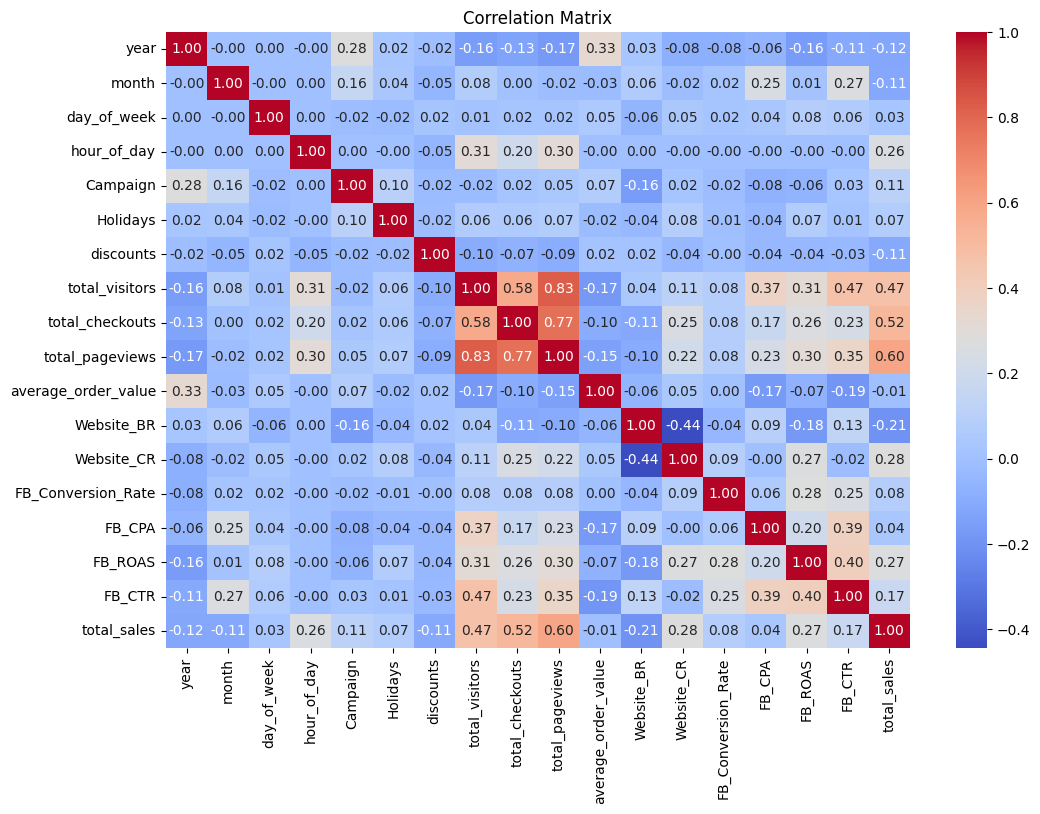

In [ ]:
# Correlation analysis
corr_matrix = final_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Assuming you want to find the variables with the highest correlation with 'total_sales'
highest_corr_variables = corr_matrix['total_sales'].abs().sort_values(ascending=False)
print(highest_corr_variables)

total_sales            1.000000
total_pageviews        0.595847
total_checkouts        0.521716
total_visitors         0.474615
Website_CR             0.280784
FB_ROAS                0.270566
hour_of_day            0.258292
Website_BR             0.207045
FB_CTR                 0.173119
year                   0.120557
month                  0.114153
Campaign               0.112047
discounts              0.110852
FB_Conversion_Rate     0.081178
Holidays               0.073214
FB_CPA                 0.039834
day_of_week            0.025547
average_order_value    0.006325
Name: total_sales, dtype: float64


In [ ]:
#check for duplicate rows
duplicate_rows = final_df[final_df.duplicated()]
print("Duplicate rows:", duplicate_rows)

Duplicate rows: Empty DataFrame
Columns: [hour, Date, year, month, day_of_week, hour_of_day, Campaign, Holidays, discounts, total_visitors, total_checkouts, total_pageviews, average_order_value, Website_BR, Website_CR, FB_Conversion_Rate, FB_CPA, FB_ROAS, FB_CTR, total_sales]
Index: []


#### Data Visualization

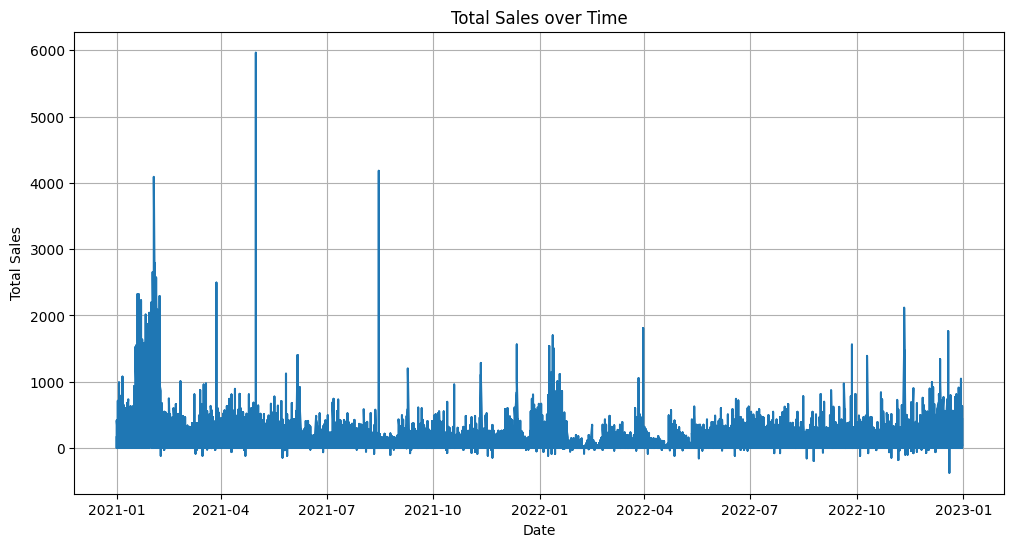

In [ ]:
# Plot the total_sales over time
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(final_df['Date'], final_df['total_sales'], linestyle='-')
plt.title('Total Sales over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

In [ ]:
tyear = final_df.groupby('year')['total_sales'].sum().reset_index()
tyear

,year,total_sales
0,2021,1351045.0
1,2022,871515.0


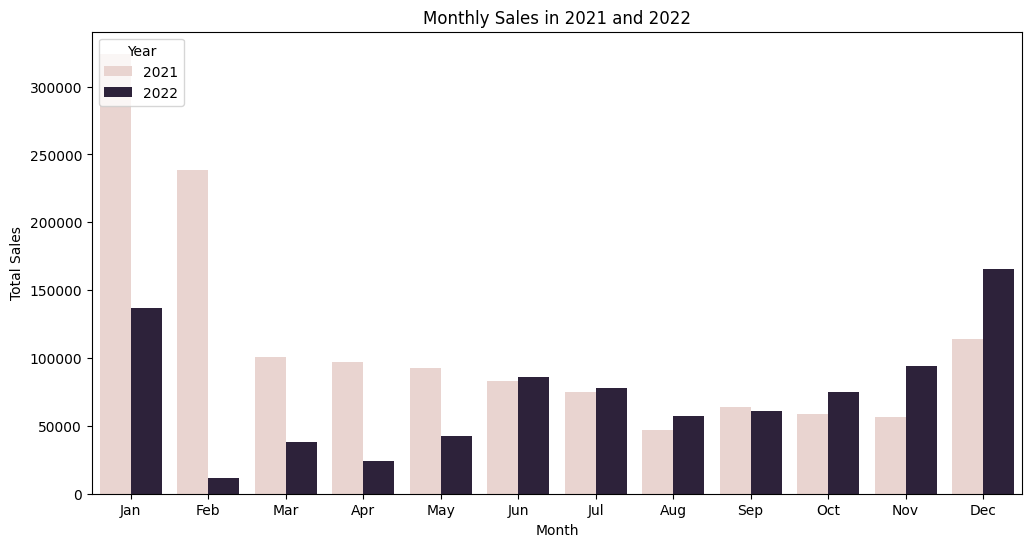

In [ ]:
# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x='month', y='total_sales', hue='year', data=monthly_sales)
plt.title('Monthly Sales in 2021 and 2022')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(0, 12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Year', loc='upper left')
plt.show()

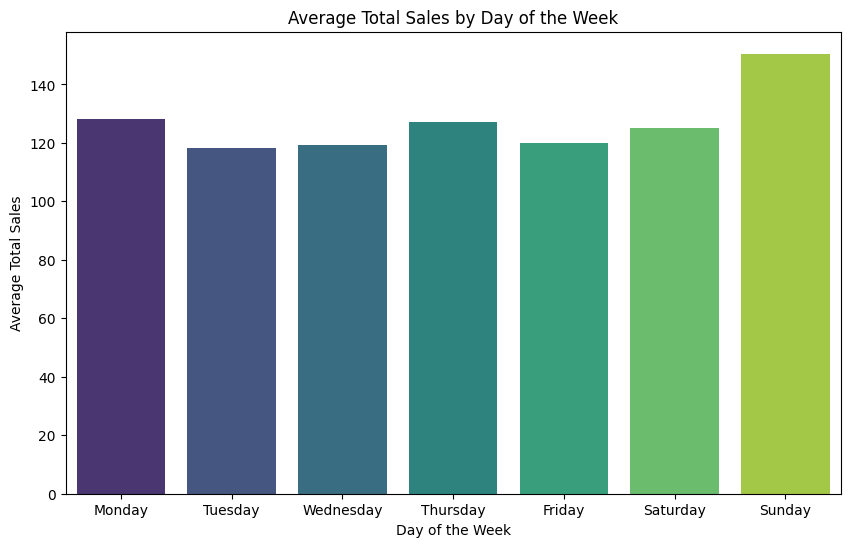

In [ ]:
# Aggregate sales data by day of the week
sales_by_day_of_week = final_df.groupby('day_of_week')['total_sales'].mean().reset_index()

# Map day of week numbers to names
day_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
sales_by_day_of_week['day_of_week'] = sales_by_day_of_week['day_of_week'].map(day_map)

# Plot the sales trend over a week
plt.figure(figsize=(10, 6))
sns.barplot(x='day_of_week', y='total_sales', data=sales_by_day_of_week, palette='viridis')
plt.title('Average Total Sales by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Total Sales')
plt.show()

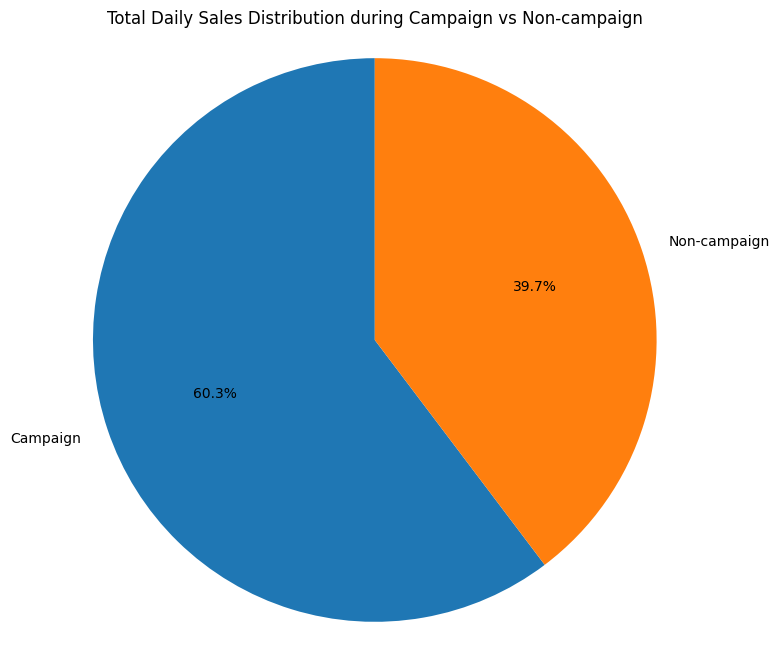

In [ ]:
# Group by Date and sum total_sales
daily_sales = final_df.groupby('Date')['total_sales'].sum().reset_index()

# Calculate total sales during campaign and non-campaign periods
campaign_daily_sales = daily_sales[daily_sales['Date'].isin(final_df[final_df['Campaign'] == 1]['Date'])]['total_sales'].sum()
non_campaign_daily_sales = daily_sales[daily_sales['Date'].isin(final_df[final_df['Campaign'] == 0]['Date'])]['total_sales'].sum()

# Pie chart
labels = ['Campaign', 'Non-campaign']
sizes = [campaign_daily_sales, non_campaign_daily_sales]
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.title('Total Daily Sales Distribution during Campaign vs Non-campaign')
plt.show()


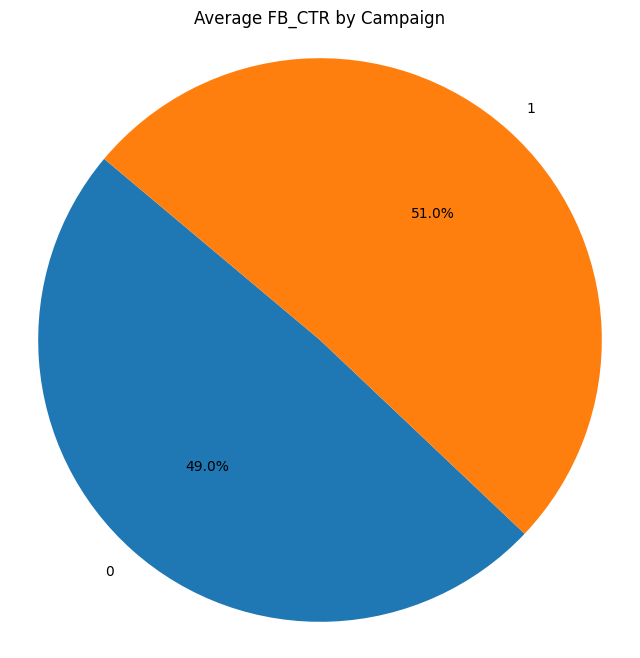

In [ ]:

# Calculate the average FB_CTR for each Campaign
campaign_ctr = final_df.groupby('Campaign')['FB_CTR'].mean().sort_values()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(campaign_ctr, labels=campaign_ctr.index, autopct='%1.1f%%', startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.title('Average FB_CTR by Campaign')
plt.show()

### Data Preparation

#### Resampling
using downsampling  (daily,weekly and monthly)

In [ ]:
# Convert 'hour' column to datetime if it's not already
final_df['hour'] = pd.to_datetime(final_df['hour'])

# Set 'hour' column as index
final_df.set_index('hour', inplace=True)

# Resample to monthly sales
monthly_sales = final_df['total_sales'].resample('M').sum()


# Assuming 'final_df' is your DataFrame containing the data
X = final_df[['day_of_week','Campaign', 'Holidays', 'discounts', 'total_visitors', 'total_checkouts', 'total_pageviews', 'average_order_value', 'Website_BR', 'FB_CTR', 'FB_Conversion_Rate', 'FB_CPA', 'FB_ROAS']]

# Resample the features and target variable to monthly frequency
X_monthly_resampled = X.resample('M').mean()

# Reset index for both
monthly_sales = monthly_sales.reset_index()


X_monthly_resampled = X_monthly_resampled.reset_index()



# Display the monthly and weekly sales data
print("Monthly Sales:")
print(monthly_sales.head(10))


Monthly Sales:
        hour  total_sales
0 2021-01-31     324214.0
1 2021-02-28     238454.0
2 2021-03-31     101092.0
3 2021-04-30      97229.0
4 2021-05-31      92429.0
5 2021-06-30      82754.0
6 2021-07-31      74770.0
7 2021-08-31      46729.0
8 2021-09-30      63784.0
9 2021-10-31      58896.0


### Stationarity
Some time-series models, such as SARIMA, assume that the underlying data is stationary.

### KPSS and ADF Test
ADF test is conducted with the following assumptions:
•	Null Hypothesis (HO): Series is non-stationary
•	Alternate Hypothesis(HA): Series is stationary

If the test statistic is less than the critical value and the p-value is less than 0.05, the null hypothesis is rejected. This indicate that the series is stationary.

 The KPSS test is conducted with the following assumptions:
•	Null Hypothesis (HO): Series is stationary
•	Alternate Hypothesis(HA): Series is non-stationary
The hypothesis is reversed in the KPSS test compared to ADF Test. The null hypothesis cannot be rejected if the test statistic is less than the critical value and the p-value is less than 0.05.


In [ ]:
# Perform KPSS test on the monthly sales(target variable)
kpss_stat, p_value, lags, critical_values = kpss(monthly_sales_transformed)
print(f'KPSS Statistic: {kpss_stat}')
print(f'p-value: {p_value}')
print(f'Critical Values: {critical_values}')

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis (non-stationary)")
else:
    print("Fail to reject the null hypothesis (stationary)")

KPSS Statistic: 0.3013342416261622
p-value: 0.1
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Fail to reject the null hypothesis (stationary)


<ipython-input-58-519e5176a6cb>:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, p_value, lags, critical_values = kpss(monthly_sales_transformed)


In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test on monthly sales
adf_result = adfuller(monthly_sales_transformed)
print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')
print('Critical Values:')
for key, value in adf_result[4].items():
    print(f'   {key}: {value}')

# Interpret the result
if adf_result[1] <= 0.05:
    print('The data is stationary')
else:
    print('The data is not stationary')

ADF Statistic: -3.3258964159995554
p-value: 0.013759849909630934
Critical Values:
   1%: -3.7529275211638033
   5%: -2.998499866852963
   10%: -2.6389669754253307
The data is stationary


In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test for each feature in X_monthly_resampled
for col in X_monthly_resampled.columns:
    result = adfuller(X_monthly_resampled[col])
    print(f'ADF Statistic for {col}: {result[0]}')
    print(f'p-value: {result[1]}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')

    # Interpret the result
    if result[1] <= 0.05:
      print('The data is stationary')
    else:
      print('The data is not stationary')


ADF Statistic for hour: 7.217624488309239
p-value: 1.0
Critical Values:
	1%: -3.769732625845229
	5%: -3.005425537190083
	10%: -2.6425009917355373
The data is not stationary
ADF Statistic for day_of_week: -4.47108590608036
p-value: 0.00022169855968854677
Critical Values:
	1%: -3.9240193847656246
	5%: -3.0684982031250003
	10%: -2.67389265625
The data is stationary
ADF Statistic for Campaign: 1.4800241370289635
p-value: 0.9974490140594453
Critical Values:
	1%: -4.01203360058309
	5%: -3.1041838775510207
	10%: -2.6909873469387753
The data is not stationary
ADF Statistic for Holidays: -4.72334134930482
p-value: 7.605475353119034e-05
Critical Values:
	1%: -3.8092091249999998
	5%: -3.0216450000000004
	10%: -2.6507125
The data is stationary
ADF Statistic for discounts: -1.8629787887415075
p-value: 0.34967235294291243
Critical Values:
	1%: -3.7529275211638033
	5%: -2.998499866852963
	10%: -2.6389669754253307
The data is not stationary
ADF Statistic for total_visitors: -0.27362530768853294
p-valu

#### Box-Cox Transformation

In [ ]:
from scipy.stats import boxcox

# Add a small constant to ensure all values are positive
constant = 1

# Apply the Box-Cox transformation
monthly_sales_transformed, lambda_value = boxcox(monthly_sales['total_sales'] + constant)

# Create a new column for the transformed values
monthly_sales['total_sales_transformed'] = monthly_sales_transformed


In [ ]:
# Calculate skewness and kurtosis for original and transformed data
skewness_original = skew(monthly_sales['total_sales'])
kurtosis_original = kurtosis(monthly_sales['total_sales'])

skewness_transformed = skew(monthly_sales_transformed)
kurtosis_transformed = kurtosis(monthly_sales_transformed)

print(f"Skewness (Original): {skewness_original}, Kurtosis (Original): {kurtosis_original}")
print(f"Skewness (Transformed): {skewness_transformed}, Kurtosis (Transformed): {kurtosis_transformed}")

Skewness (Original): 2.0112140635268405, Kurtosis (Original): 4.099051417471646
Skewness (Transformed): 0.029884343739539444, Kurtosis (Transformed): 0.9351680722251237


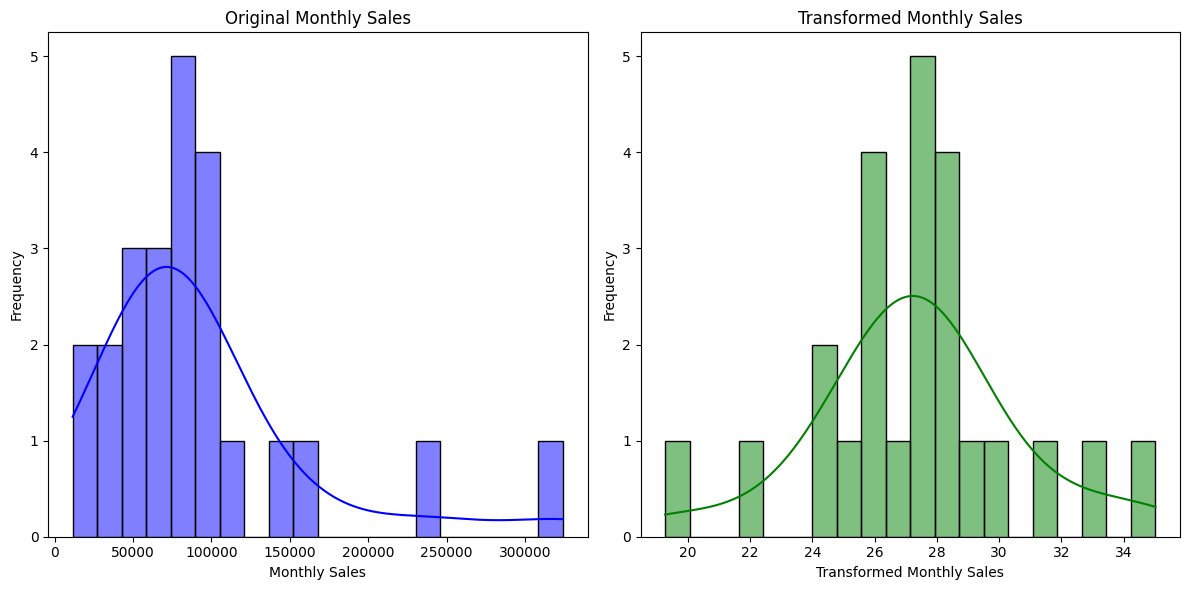

In [ ]:
# Plot the original and transformed data side by side
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(monthly_sales['total_sales'], kde=True, color='blue', bins=20)
plt.title('Original Monthly Sales')
plt.xlabel('Monthly Sales')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(monthly_sales_transformed, kde=True, color='green', bins=20)
plt.title('Transformed Monthly Sales')
plt.xlabel('Transformed Monthly Sales')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Box-cox transformation

In [ ]:
# Apply Box-Cox transformation to non-stationary features
non_stationary_features = [ 'average_order_value', 'FB_CTR','FB_CPA','total_checkouts','Campaign']
for feature in non_stationary_features:
    X_monthly_resampled[feature + '_transformed'], _ = stats.boxcox(X_monthly_resampled[feature] + 1)

# Check stationarity of transformed features
for feature in non_stationary_features:
    adf_result = adfuller(X_monthly_resampled[feature + '_transformed'])
    if adf_result[1] <= 0.05:
        print(f'The transformed {feature} data is stationary')
    else:
        print(f'The transformed {feature} data is not stationary')



The transformed average_order_value data is stationary
The transformed FB_CTR data is not stationary
The transformed FB_CPA data is stationary
The transformed total_checkouts data is not stationary
The transformed Campaign data is not stationary


In [ ]:
# Remove total_visitors and total_checkouts from X_monthly_resampled
X_monthly_resampled = X_monthly_resampled.drop(['FB_CPA','total_checkouts','total_visitors','total_pageviews','average_order_value','FB_CTR'], axis=1)

In [ ]:
print(X_monthly_resampled.head())

        hour  day_of_week  Campaign  Holidays  discounts  Website_BR  \
0 2021-01-31     3.193548  0.419355  0.129032 -22.537634    0.618956   
1 2021-02-28     3.000000  0.285714  0.178571  -5.197917    0.642134   
2 2021-03-31     2.806452  0.000000  0.000000 -18.409946    0.657795   
3 2021-04-30     3.033333  0.166667  0.066667  -5.212500    0.654166   
4 2021-05-31     3.064516  0.548387  0.290323  -5.315860    0.640143   

   FB_Conversion_Rate   FB_ROAS  average_order_value_transformed  \
0            0.148414  7.161835                         0.595226   
1            0.098091  6.848980                         0.595348   
2            0.111916  5.587434                         0.595360   
3            0.101661  5.268496                         0.595393   
4            0.068196  3.622621                         0.595332   

   FB_CTR_transformed  FB_CPA_transformed  total_checkouts_transformed  \
0            0.730876            8.508698                     0.368313   
1         

### Differencing

In [ ]:
# Difference for 'discounts'
X_monthly_resampled['discount_diff'] = X_monthly_resampled['discounts'] - X_monthly_resampled['discounts'].shift(1)

# Difference for 'FB_CTR_transformed'
X_monthly_resampled['FB_CTR_transformed_diff'] = X_monthly_resampled['FB_CTR_transformed'] - X_monthly_resampled['FB_CTR_transformed'].shift(1)

X_monthly_resampled['total_checkouts_transformed_diff'] = X_monthly_resampled['total_checkouts_transformed'] - X_monthly_resampled['total_checkouts_transformed'].shift(1)


# Fill NaN values with 0
X_monthly_resampled = X_monthly_resampled.fillna(0)

# Check the stationarity of the differenced variables using ADF test
from statsmodels.tsa.stattools import adfuller

adf_result_discount = adfuller(X_monthly_resampled['discount_diff'])
print("ADF Statistic for discount:", adf_result_discount[0])
print("p-value for discount:", adf_result_discount[1])

adf_result_FB_CTR = adfuller(X_monthly_resampled['FB_CTR_transformed_diff'])
print("ADF Statistic for FB_CTR_transformed:", adf_result_FB_CTR[0])
print("p-value for FB_CTR_transformed:", adf_result_FB_CTR[1])


adf_result_chekout = adfuller(X_monthly_resampled['total_checkouts_transformed_diff'])
print("ADF Statistic for total_checkouts_transformed_diff:", adf_result_chekout[0])
print("p-value for total_checkouts_transformed_diff:", adf_result_chekout[1])





ADF Statistic for discount: -5.122769714856695
p-value for discount: 1.261394701190704e-05
ADF Statistic for FB_CTR_transformed: -6.207535002804192
p-value for FB_CTR_transformed: 5.610185862146844e-08
ADF Statistic for total_checkouts_transformed_diff: -3.8997292164402215
p-value for total_checkouts_transformed_diff: 0.0020368408282322305


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm


# Detrending Campaign
y_campaign = X_monthly_resampled['Campaign_transformed']
x_campaign = np.arange(len(y_campaign))  # Assuming time is the index
x_campaign = sm.add_constant(x_campaign)
model_campaign = sm.OLS(y_campaign, x_campaign)
results_campaign = model_campaign.fit()
trend_campaign = results_campaign.predict(x_campaign)
X_monthly_resampled['Campaign_detrended'] = y_campaign - trend_campaign


In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss


# ADF and KPSS tests for Campaign_detrended
adf_result_campaign = adfuller(X_monthly_resampled['Campaign_detrended'].dropna())
kpss_result_campaign = kpss(X_monthly_resampled['Campaign_detrended'].dropna(), regression='c')

print("ADF Statistic for Campaign_detrended:", adf_result_campaign[0])
print("p-value for Campaign_detrended:", adf_result_campaign[1])
print("KPSS Statistic for Campaign_detrended:", kpss_result_campaign[0])
print("p-value for Campaign_detrended:", kpss_result_campaign[1])


ADF Statistic for Campaign_detrended: -3.921635331601721
p-value for Campaign_detrended: 0.0018812684200698857
KPSS Statistic for Campaign_detrended: 0.1897783545342508
p-value for Campaign_detrended: 0.1


<ipython-input-66-17badc7a4f64>:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result_campaign = kpss(X_monthly_resampled['Campaign_detrended'].dropna(), regression='c')


All variable are stationary

In [ ]:
print(X_monthly_resampled.columns)

Index(['hour', 'day_of_week', 'Campaign', 'Holidays', 'discounts',
       'Website_BR', 'FB_Conversion_Rate', 'FB_ROAS',
       'average_order_value_transformed', 'FB_CTR_transformed',
       'FB_CPA_transformed', 'total_checkouts_transformed',
       'Campaign_transformed', 'discount_diff', 'FB_CTR_transformed_diff',
       'total_checkouts_transformed_diff', 'Campaign_detrended'],
      dtype='object')


In [ ]:
# Remove the original variables
X_monthly_resampled = X_monthly_resampled.drop(['total_checkouts_transformed','Campaign_transformed','discounts', 'FB_CTR_transformed',], axis=1)

# Check the columns in X_monthly_resampled to confirm the removal
print(X_monthly_resampled.columns)

Index(['hour', 'day_of_week', 'Campaign', 'Holidays', 'Website_BR',
       'FB_Conversion_Rate', 'FB_ROAS', 'average_order_value_transformed',
       'FB_CPA_transformed', 'discount_diff', 'FB_CTR_transformed_diff',
       'total_checkouts_transformed_diff', 'Campaign_detrended'],
      dtype='object')


In [ ]:
print("Number of rows:", X_monthly_resampled.shape[0])

Number of rows: 24


In [ ]:
print(X_monthly_resampled.head())

        hour  day_of_week  Campaign  Holidays  Website_BR  FB_Conversion_Rate  \
0 2021-01-31     3.193548  0.419355  0.129032    0.618956            0.148414   
1 2021-02-28     3.000000  0.285714  0.178571    0.642134            0.098091   
2 2021-03-31     2.806452  0.000000  0.000000    0.657795            0.111916   
3 2021-04-30     3.033333  0.166667  0.066667    0.654166            0.101661   
4 2021-05-31     3.064516  0.548387  0.290323    0.640143            0.068196   

    FB_ROAS  average_order_value_transformed  FB_CPA_transformed  \
0  7.161835                         0.595226            8.508698   
1  6.848980                         0.595348            9.209392   
2  5.587434                         0.595360           10.281691   
3  5.268496                         0.595393            7.680155   
4  3.622621                         0.595332            8.855370   

   discount_diff  FB_CTR_transformed_diff  total_checkouts_transformed_diff  \
0       0.000000         

### Split the dataset

In [ ]:
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit

# Assuming monthly_sales_transformed is a numpy array
monthly_sales_transformed_df = pd.DataFrame(monthly_sales_transformed, index=X_monthly_resampled.index, columns=['monthly_sales_transformed'])

tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X_monthly_resampled):
    train_size = int(len(train_index) * 0.8)  # Use 80% of the data for training
    train_index, val_index = train_index[:train_size], train_index[train_size:]

    X_train, X_val = X_monthly_resampled.iloc[train_index], X_monthly_resampled.iloc[val_index]
    y_train, y_val = monthly_sales_transformed_df.iloc[train_index], monthly_sales_transformed_df.iloc[val_index]

for i, (train_index, test_index) in enumerate(tscv.split(X_monthly_resampled)):
    print(f"Fold {i+1}:")
    print(f"  Train indices: {train_index}")
    print(f"  Validation indices: {test_index}")
    print(f"  Length of training set: {len(train_index)}, Length of validation set: {len(test_index)}")




Fold 1:
  Train indices: [0 1 2 3]
  Validation indices: [4 5 6 7]
  Length of training set: 4, Length of validation set: 4
Fold 2:
  Train indices: [0 1 2 3 4 5 6 7]
  Validation indices: [ 8  9 10 11]
  Length of training set: 8, Length of validation set: 4
Fold 3:
  Train indices: [ 0  1  2  3  4  5  6  7  8  9 10 11]
  Validation indices: [12 13 14 15]
  Length of training set: 12, Length of validation set: 4
Fold 4:
  Train indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
  Validation indices: [16 17 18 19]
  Length of training set: 16, Length of validation set: 4
Fold 5:
  Train indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
  Validation indices: [20 21 22 23]
  Length of training set: 20, Length of validation set: 4


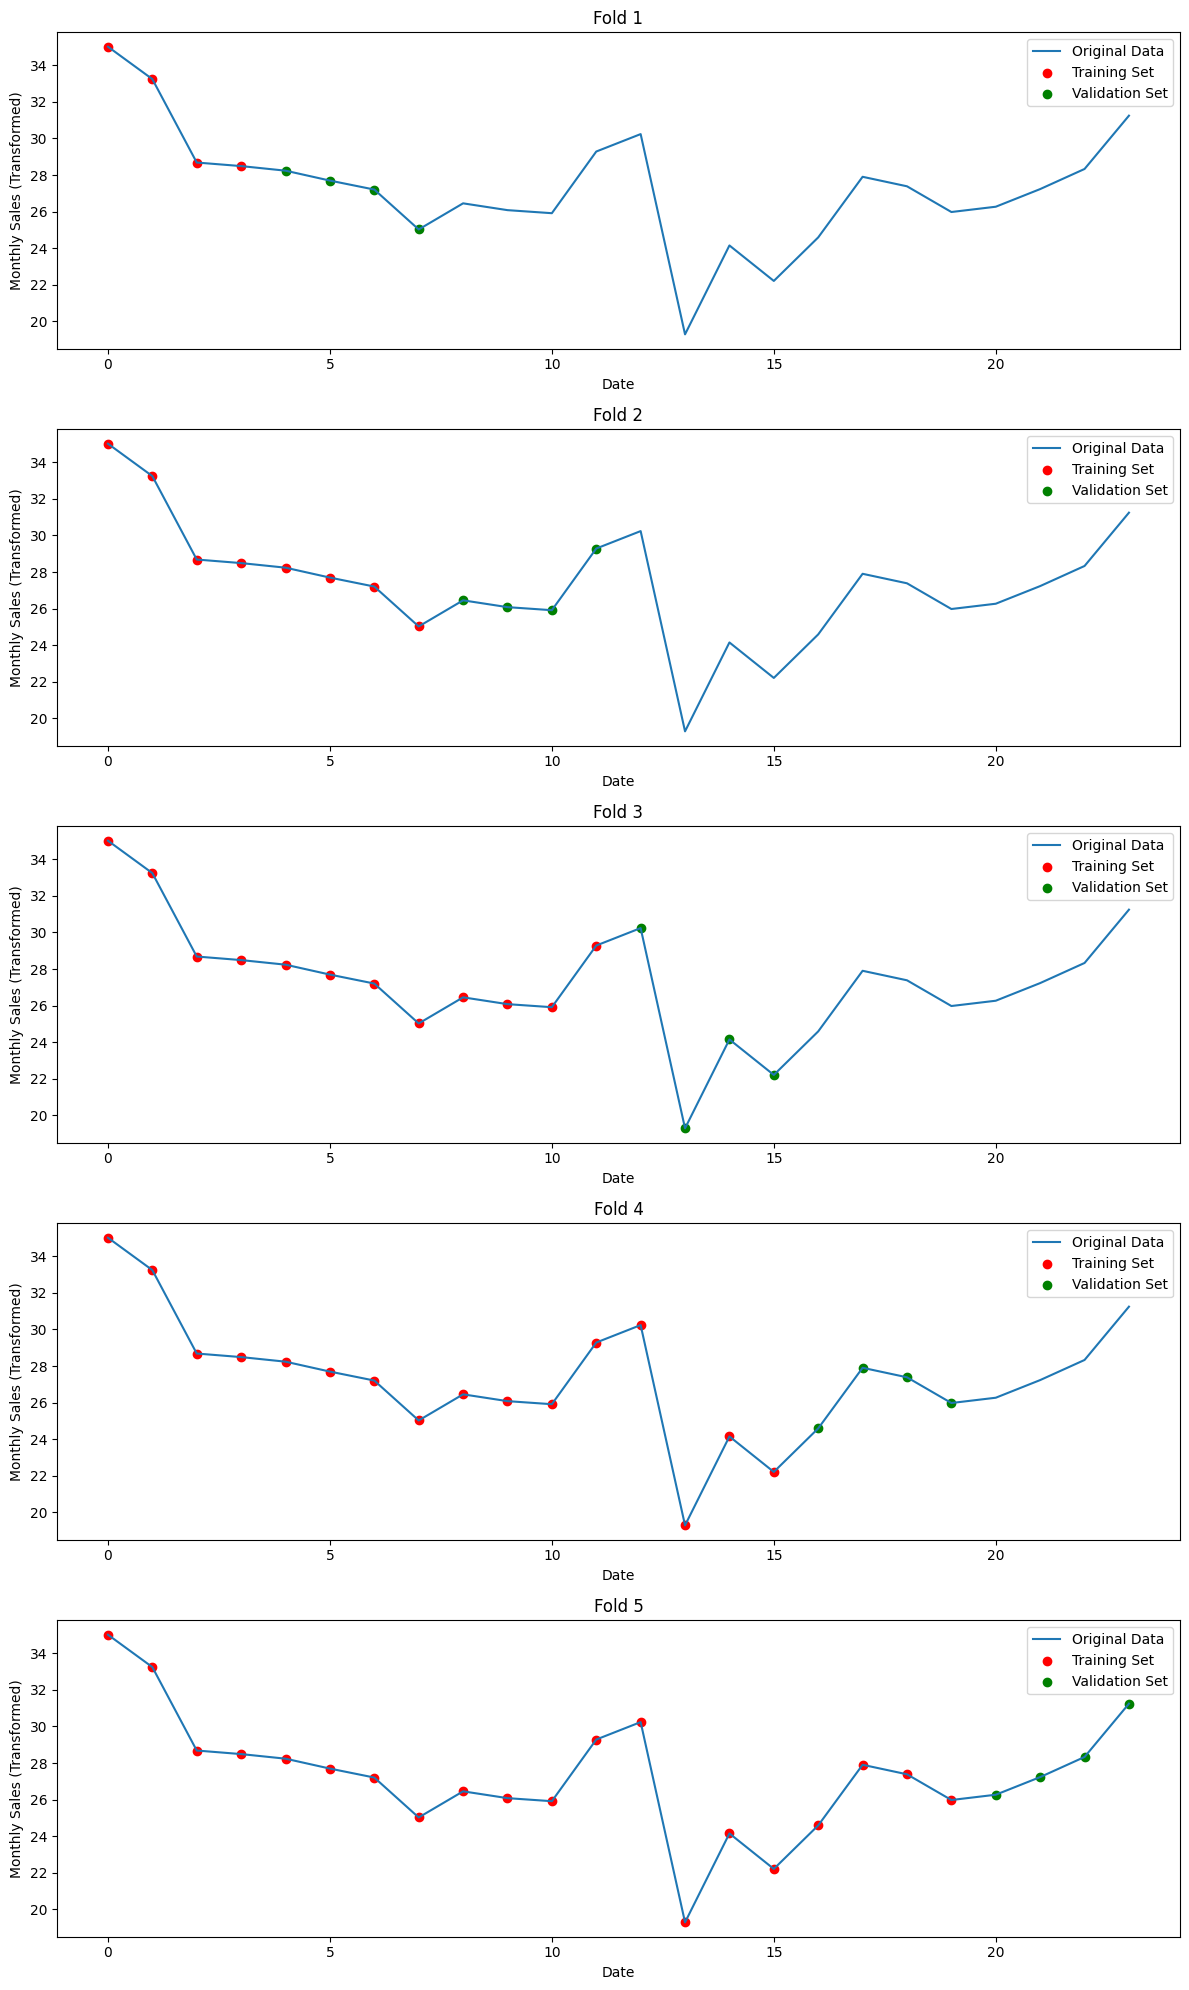

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

folds = 5
fig, axs = plt.subplots(folds, figsize=(12, folds*4))

for i, (train_index, val_index) in enumerate(tscv.split(X_monthly_resampled)):
    X_train, X_val = X_monthly_resampled.iloc[train_index], X_monthly_resampled.iloc[val_index]
    y_train, y_val = monthly_sales_transformed_df.iloc[train_index], monthly_sales_transformed_df.iloc[val_index]

    axs[i].plot(X_monthly_resampled.index, monthly_sales_transformed_df['monthly_sales_transformed'], label='Original Data')
    axs[i].scatter(monthly_sales_transformed_df.index[train_index], y_train, color='red', label='Training Set')
    axs[i].scatter(monthly_sales_transformed_df.index[val_index], y_val, color='green', label='Validation Set')
    axs[i].set_xlabel('Date')
    axs[i].set_ylabel('Monthly Sales (Transformed)')
    axs[i].set_title(f'Fold {i+1}')
    axs[i].legend()

plt.tight_layout()
plt.show()




### Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# List of datetime columns
datetime_cols = ['hour', 'day_of_week']  # Add other datetime columns as needed

# List of columns to exclude from scaling
exclude_cols = ['day_of_week',  'Campaign_detrended','Holidays','Campaign']

# List of columns to scale (excluding datetime and excluded columns)
cols_to_scale = [col for col in X_monthly_resampled.columns if col not in datetime_cols and col not in exclude_cols]

# Create a StandardScaler object
scaler = StandardScaler()

# Scale the non-datetime columns
X_monthly_resampled_scaled = X_monthly_resampled.copy()
X_monthly_resampled_scaled[cols_to_scale] = scaler.fit_transform(X_monthly_resampled[cols_to_scale])

# Use the same scaler to transform the validation set
X_val_scaled = X_val.copy()
X_val_scaled[cols_to_scale] = scaler.transform(X_val[cols_to_scale])


### Feature Engineering

### Lag

In [ ]:
import pandas as pd

# Assuming y_train is a DataFrame with a single column
y_train_series = pd.Series(y_train.iloc[:, 0].values, index=X_train.index)

# Assuming y_val is a DataFrame with a single column
y_val_series = pd.Series(y_val.iloc[:, 0].values, index=X_val.index)

# Create lag features for the target variable 'total_sales'
lag_steps = 1  # Number of lag steps

# Create lag features for the target variable 'monthly_sales_transformed'
for i in range(1, lag_steps + 1):
    X_train[f'monthly_sales_transformed_lag_{i}'] = y_train_series.shift(i)
    X_val[f'monthly_sales_transformed_lag_{i}'] = y_val_series.shift(i)

# Replace NaN values with 0
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)

# Check the new DataFrames with lag features
print(X_train.head())
print(X_val.head())




        hour  day_of_week  Campaign  Holidays  Website_BR  FB_Conversion_Rate  \
0 2021-01-31     3.193548  0.419355  0.129032    0.618956            0.148414   
1 2021-02-28     3.000000  0.285714  0.178571    0.642134            0.098091   
2 2021-03-31     2.806452  0.000000  0.000000    0.657795            0.111916   
3 2021-04-30     3.033333  0.166667  0.066667    0.654166            0.101661   
4 2021-05-31     3.064516  0.548387  0.290323    0.640143            0.068196   

    FB_ROAS  average_order_value_transformed  FB_CPA_transformed  \
0  7.161835                         0.595226            8.508698   
1  6.848980                         0.595348            9.209392   
2  5.587434                         0.595360           10.281691   
3  5.268496                         0.595393            7.680155   
4  3.622621                         0.595332            8.855370   

   discount_diff  FB_CTR_transformed_diff  total_checkouts_transformed_diff  \
0       0.000000         

### Seasonality

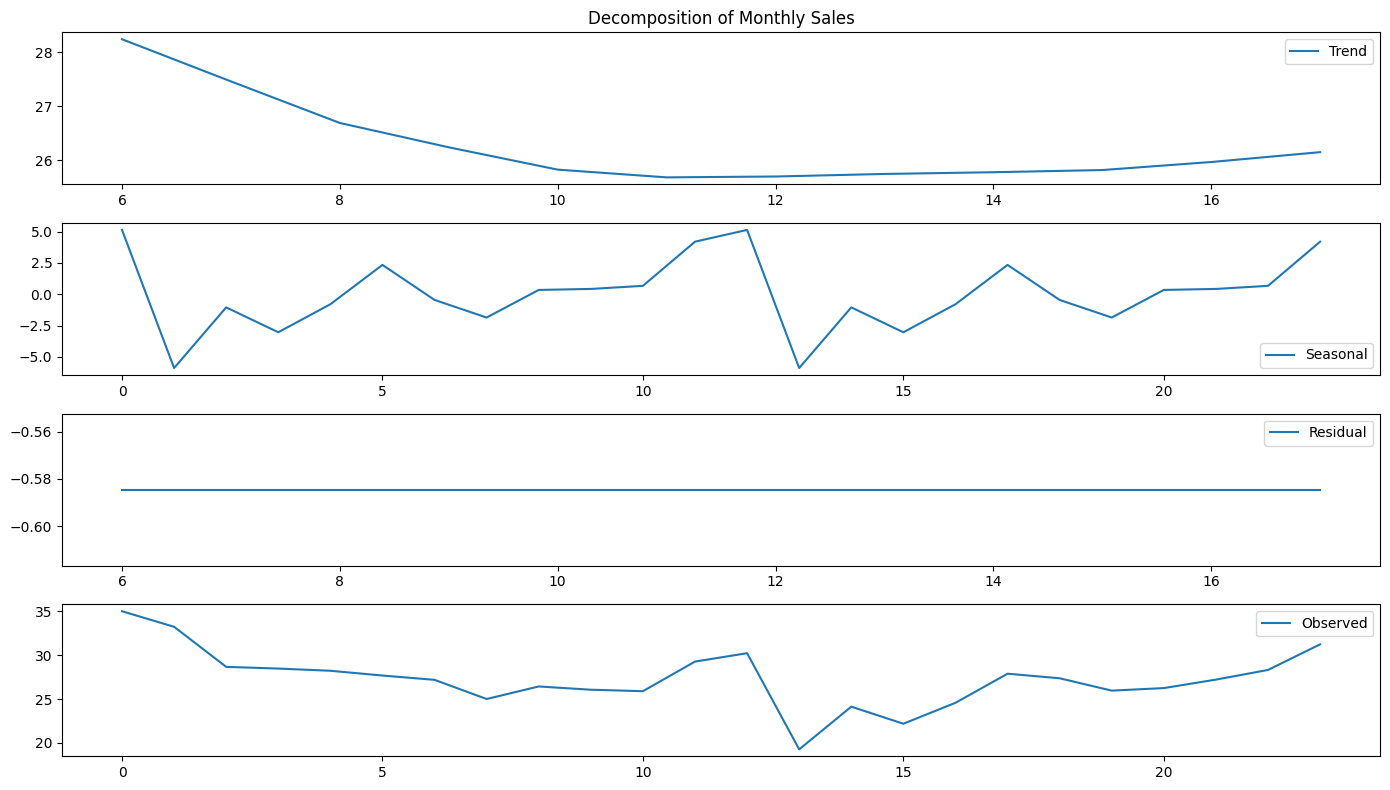

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Decompose monthly sales
sales_decomposition = seasonal_decompose(monthly_sales_transformed, model='additive', period=12)


# Plot the decomposed components
plt.figure(figsize=(14, 8))

plt.subplot(4, 1, 1)
plt.plot(sales_decomposition.trend, label='Trend')
plt.legend()
plt.title('Decomposition of Monthly Sales')

plt.subplot(4, 1, 2)
plt.plot(sales_decomposition.seasonal, label='Seasonal')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(sales_decomposition.resid, label='Residual')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(sales_decomposition.observed, label='Observed')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Check the shape of the new DataFrames with lag features
print("X_train_reset shape:", X_train.shape)
print("X_val_reset shape:", X_val.shape)

X_train_reset shape: (20, 14)
X_val_reset shape: (4, 14)


In [ ]:
# Check the shape of the new DataFrames with lag features
print("y_train_reset shape:", y_train.shape)
print("y_val_reset shape:", y_val.shape)

y_train_reset shape: (20, 1)
y_val_reset shape: (4, 1)


In [ ]:
print(X_monthly_resampled.head())


        hour  day_of_week  Campaign  Holidays  Website_BR  FB_Conversion_Rate  \
0 2021-01-31     3.193548  0.419355  0.129032    0.618956            0.148414   
1 2021-02-28     3.000000  0.285714  0.178571    0.642134            0.098091   
2 2021-03-31     2.806452  0.000000  0.000000    0.657795            0.111916   
3 2021-04-30     3.033333  0.166667  0.066667    0.654166            0.101661   
4 2021-05-31     3.064516  0.548387  0.290323    0.640143            0.068196   

    FB_ROAS  average_order_value_transformed  FB_CPA_transformed  \
0  7.161835                         0.595226            8.508698   
1  6.848980                         0.595348            9.209392   
2  5.587434                         0.595360           10.281691   
3  5.268496                         0.595393            7.680155   
4  3.622621                         0.595332            8.855370   

   discount_diff  FB_CTR_transformed_diff  total_checkouts_transformed_diff  \
0       0.000000         

## Modeling

### SARIMA model

### Find the optimal number of SARIMA model

In [ ]:
pip install pmdarima

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 8.8 MB/s eta 0:00:00


In [ ]:
import pmdarima as pm

# Fit the seasonal auto-ARIMA model with exogenous variables
smodel = pm.auto_arima(y_train, exogenous=X_train,
                        start_p=1, start_q=1,
                        test='adf',
                        max_p=3, max_q=3, m=12,
                        start_P=0, seasonal=True,
                        d=1, D=1, trace=True,
                        error_action='ignore',
                        suppress_warnings=True,
                        stepwise=True)

# Summary of the best-fitting SARIMA model
print(smodel.summary())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=inf, Time=0.52 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=45.303, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=inf, Time=0.66 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=47.577, Time=0.16 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=47.303, Time=0.04 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=47.303, Time=0.04 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=49.303, Time=0.05 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=44.306, Time=0.04 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=inf, Time=0.26 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=48.258, Time=0.49 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=46.141, Time=0.05 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=46.241, Time=0.22 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=45.577, Time=0.13 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=inf, Time=0.80 sec
 ARIMA(1,1,0)(0,1,0)[12] intercept   : AIC=42.439, Time=0.1

In [ ]:

# Drop datetime columns from X_train and X_val
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_val_numeric = X_val.select_dtypes(include=[np.number])

# Drop 'Holidays_detrended' and 'Campaign_detrended' columns
X_train_numeric = X_train_numeric.drop([ 'Campaign'], axis=1)
X_val_numeric = X_val_numeric.drop(['Campaign'], axis=1)

# Convert y_train and X_train to numpy arrays with float data types
y_train_array = y_train.values.astype(float)
X_train_array = X_train_numeric.values.astype(float)

# Convert X_val to numpy array
X_val_array = X_val_numeric.values.astype(float)





In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

# Assuming 'train_data' is your training data and 'test_data' is your test data
order = (3, 1, 0)  # ARIMA(p, d, q)
seasonal_order = (0,1,0,12)  # SARIMA(P, D, Q, s), where s is the seasonal period

# Create and fit the SARIMAX model
sarimax_model = SARIMAX(y_train_array, exog=X_train_array, order=order, seasonal_order=seasonal_order)
sarimax_fit = sarimax_model.fit()


# Make predictions
predictions_sarima = sarimax_fit.predict(start=0, end=len(X_val)-1, exog=X_val_array)

# Calculate metrics
score_mae_SARIMA = mean_absolute_error(y_val, predictions_sarima)
score_rmse_SARIMA = math.sqrt(mean_squared_error(y_val, predictions_sarima))

print("Mean Absolute Error of SARIMA:", score_mae_SARIMA)
print("Root Mean Squared Error of SARIMA:", score_rmse_SARIMA)

# Calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Assuming y_val is your actual values and predictions_sarima is your predicted values
mape_sarima = mean_absolute_percentage_error(y_val, predictions_sarima)

print(f"Mean Absolute Percentage Error of SARIMA: {mape_sarima:.2f}%")


Mean Absolute Error of SARIMA: 11.18525198249565
Root Mean Squared Error of SARIMA: 12.481465391215833
Mean Absolute Percentage Error of SARIMA: 39.84%


/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


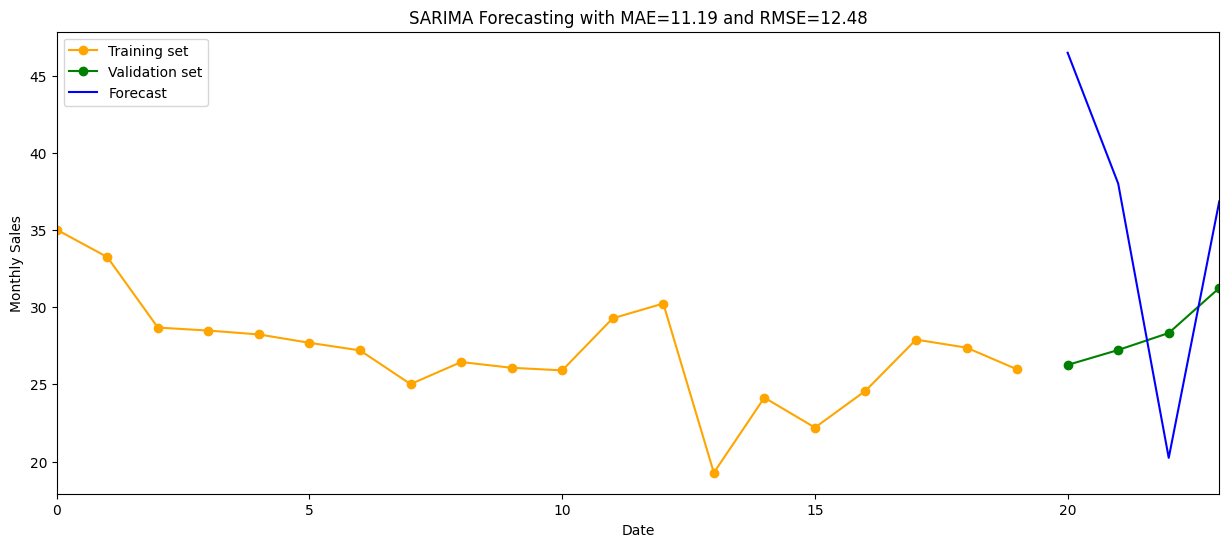

In [ ]:
# Plotting
plt.figure(figsize=(15, 6))
plt.plot(y_train.index, y_train, label='Training set', color='orange',marker='o')
plt.plot(y_val.index, y_val, label='Validation set', color='green', marker='o')
plt.plot(y_val.index, predictions_sarima, label='Forecast', color='blue')
plt.title(f'SARIMA Forecasting with MAE={score_mae_SARIMA:.2f} and RMSE={score_rmse_SARIMA:.2f}')
plt.xlabel('Date')
plt.ylabel('Monthly Sales')
plt.legend()
# Set the limits of the x-axis
plt.xlim(y_train.index.min(), y_val.index.max())
plt.show()


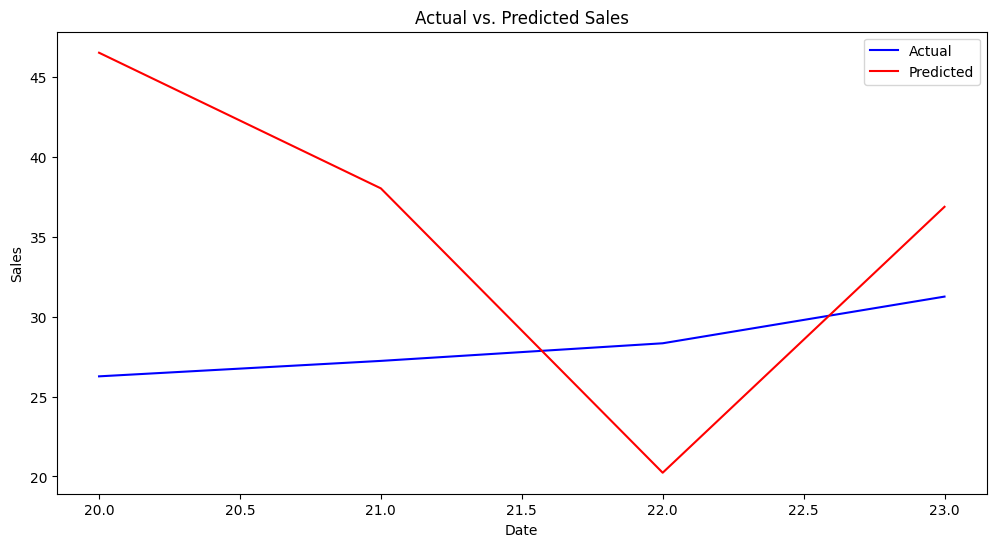

In [ ]:
import matplotlib.pyplot as plt

# Plot actual vs. predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_val.index, y_val, label='Actual', color='blue')
plt.plot(y_val.index, predictions_sarima, label='Predicted', color='red')
plt.title('Actual vs. Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()


In [ ]:
SARIMA_df = pd.DataFrame({'Actual': y_val.values.flatten(), 'Predicted': predictions_sarima.flatten()})

SARIMA_df

,Actual,Predicted
0,26.262583,46.502585
1,27.229263,38.018710
2,28.330695,20.235026
3,31.250379,36.866269


### Holt-Winter’s Exponential Smoothing

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Assuming 'train_data' is your training data
expmodel = ExponentialSmoothing(y_train_array, trend='add', seasonal='add', seasonal_periods=6)
expmodel_fit = expmodel.fit()

exp_predictions = expmodel_fit.forecast(len(X_val_array))


# Calculate metrics
mae_exp = mean_absolute_error(y_val, exp_predictions)
rmse_exp = math.sqrt(mean_squared_error(y_val, exp_predictions))

print("Mean Absolute Error:", mae_exp)
print("Root Mean Squared Error:", rmse_exp)

mape_exp = mean_absolute_percentage_error(y_val, exp_predictions)

print(f"Mean Absolute Percentage Error of Holt-Winter’s Exponential Smoothing:{mape_exp:.2f}%")

Mean Absolute Error: 5.8556376569356035
Root Mean Squared Error: 5.9651840871293835
Mean Absolute Percentage Error of Holt-Winter’s Exponential Smoothing:20.38%


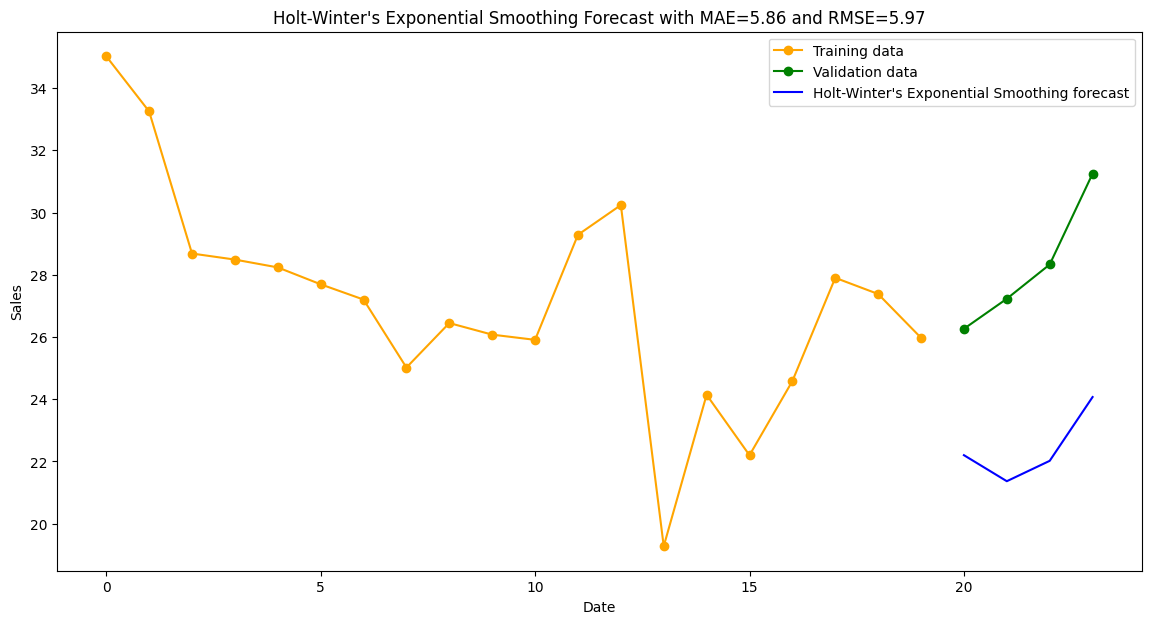

In [ ]:
import matplotlib.pyplot as plt

# Plotting the forecast
plt.figure(figsize=(14, 7))
plt.plot(y_train.index, y_train, label='Training data',color='orange',marker='o')
plt.plot(y_val.index, y_val, label='Validation data', color='green', marker='o')
plt.plot(y_val.index, exp_predictions, label='Holt-Winter\'s Exponential Smoothing forecast', color='blue')
plt.legend()
plt.title(f'Holt-Winter\'s Exponential Smoothing Forecast with MAE={mae_exp:.2f} and RMSE={rmse_exp:.2f}')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()


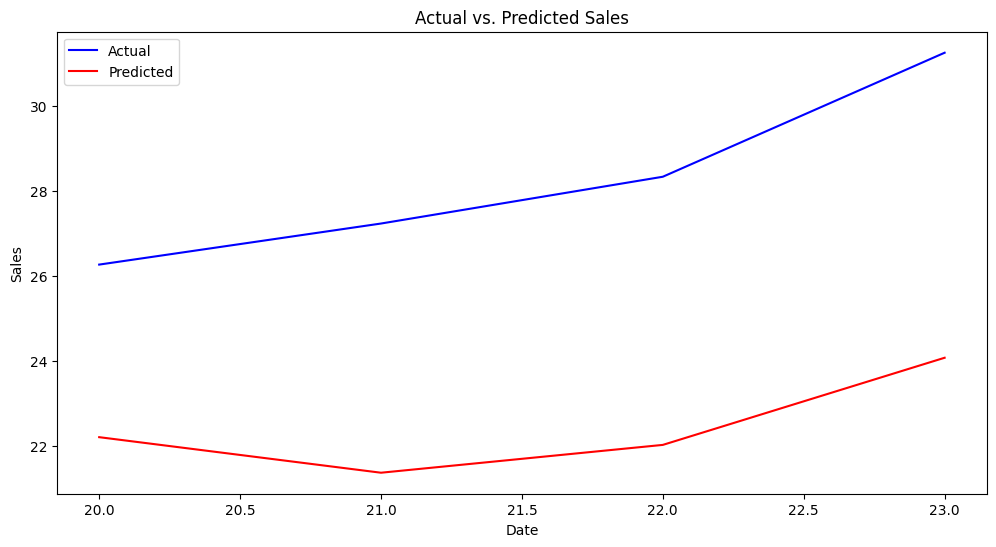

In [ ]:
import matplotlib.pyplot as plt

# Plot actual vs. predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_val.index, y_val, label='Actual', color='blue')
plt.plot(y_val.index, exp_predictions, label='Predicted', color='red')
plt.title('Actual vs. Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [ ]:
exp_df = pd.DataFrame({'Actual': y_val.values.flatten(), 'Predicted': exp_predictions.flatten()})

exp_df

,Actual,Predicted
0,26.262583,22.199846
1,27.229263,21.362971
2,28.330695,22.018048
3,31.250379,24.069505


### LSTM

In [ ]:
# Drop datetime columns from X_train and X_val
X_train_numeric_m = X_train.select_dtypes(include=[np.number])
X_val_numeric_m = X_val.select_dtypes(include=[np.number])

# Drop 'Holidays_detrended' and 'Campaign_detrended' columns
X_train_numeric_m = X_train_numeric_m.drop([ 'Campaign_detrended'], axis=1)
X_val_numeric_m = X_val_numeric_m.drop([ 'Campaign_detrended'], axis=1)

# Convert y_train and X_train to numpy arrays with float data types
y_train_array_m = y_train.values.astype(float)
X_train_array_m = X_train_numeric_m.values.astype(float)

# Convert X_val to numpy array
X_val_array_m= X_val_numeric_m.values.astype(float)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.callbacks import EarlyStopping

# Reshape X_train_array and X_val_array for LSTM input
X_train_lstm = X_train_array_m.reshape((X_train_array_m.shape[0], 1, X_train_array_m.shape[1]))
X_val_lstm = X_val_array_m.reshape((X_val_array_m.shape[0], 1, X_val_array_m.shape[1]))

# Create LSTM model
model = Sequential()
model.add(LSTM(100, activation='relu', input_shape=(1, X_train_array_m.shape[1]), return_sequences=True))
model.add(BatchNormalization())
model.add(LSTM(50, activation='relu'))
model.add(Dense(1))
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Fit model
model.fit(X_train_lstm, y_train_array, epochs=300, batch_size=32, verbose=2, validation_data=(X_val_lstm, y_val))

# Define early stopping criteria
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fit model with early stopping
model.fit(X_train_lstm, y_train_array, epochs=300, batch_size=32, verbose=2,
          validation_data=(X_val_lstm, y_val), callbacks=[early_stopping])

# Make predictions
y_pred_lstm = model.predict(X_val_lstm, verbose=0)

# Calculate metrics
mae_lstm = mean_absolute_error(y_val, y_pred_lstm)
rmse_lstm = mean_squared_error(y_val, y_pred_lstm, squared=False)

print("Mean Absolute Error (LSTM):", mae_lstm)
print("Root Mean Squared Error (LSTM):", rmse_lstm)


Epoch 1/300
1/1 - 9s - loss: 755.0867 - val_loss: 800.4868 - 9s/epoch - 9s/step
Epoch 2/300
1/1 - 0s - loss: 751.0737 - val_loss: 799.7560 - 71ms/epoch - 71ms/step
Epoch 3/300
1/1 - 0s - loss: 747.3024 - val_loss: 799.0715 - 77ms/epoch - 77ms/step
Epoch 4/300
1/1 - 0s - loss: 743.7139 - val_loss: 798.4565 - 79ms/epoch - 79ms/step
Epoch 5/300
1/1 - 0s - loss: 740.2092 - val_loss: 797.9183 - 118ms/epoch - 118ms/step
Epoch 6/300
1/1 - 0s - loss: 736.7563 - val_loss: 797.4510 - 114ms/epoch - 114ms/step
Epoch 7/300
1/1 - 0s - loss: 733.4095 - val_loss: 797.0482 - 108ms/epoch - 108ms/step
Epoch 8/300
1/1 - 0s - loss: 730.0349 - val_loss: 796.6997 - 148ms/epoch - 148ms/step
Epoch 9/300
1/1 - 0s - loss: 726.6216 - val_loss: 796.3719 - 185ms/epoch - 185ms/step
Epoch 10/300
1/1 - 0s - loss: 723.0702 - val_loss: 796.0486 - 92ms/epoch - 92ms/step
Epoch 11/300
1/1 - 0s - loss: 719.3898 - val_loss: 795.7153 - 86ms/epoch - 86ms/step
Epoch 12/300
1/1 - 0s - loss: 715.5219 - val_loss: 795.3221 - 79ms/e

Mean Absolute Error (LSTM): 6.157830083474431
Root Mean Squared Error (LSTM): 8.18809927013295


In [ ]:
mape_lstm = mean_absolute_percentage_error(y_val, y_pred_lstm)

print(f"Mean Absolute Percentage Error of LSTM:{mape_lstm:.2f}%")

Mean Absolute Percentage Error of LSTM:21.70%


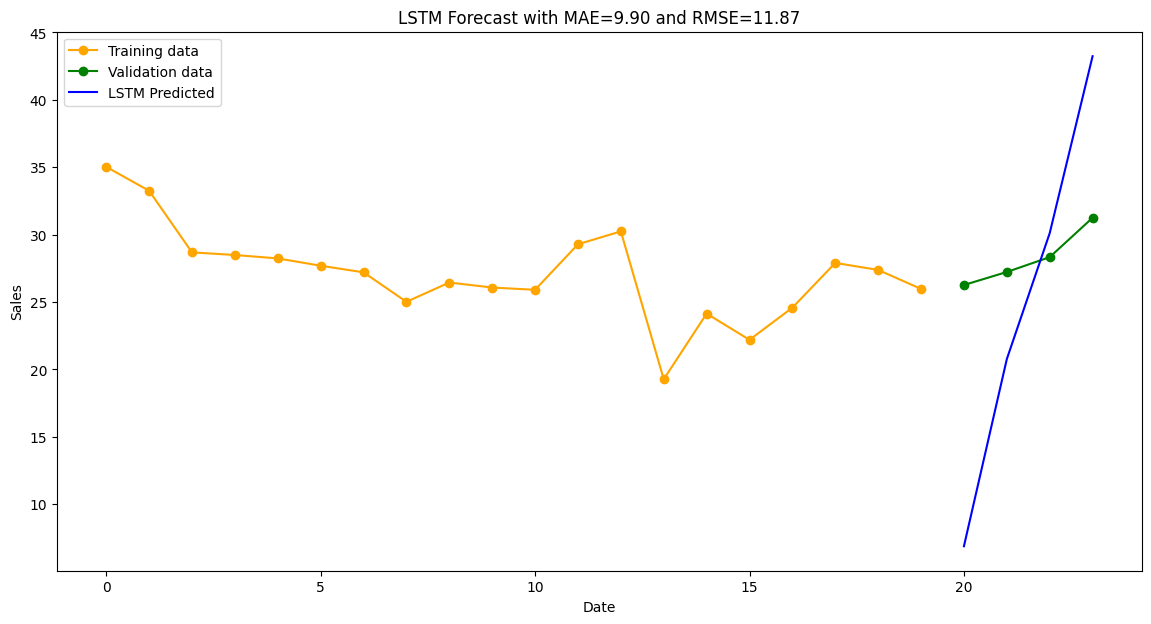

In [ ]:
import matplotlib.pyplot as plt

# Plot actual vs predicted values
plt.figure(figsize=(14, 7))
plt.plot(y_train.index, y_train, label='Training data',color='orange',marker='o')
plt.plot(y_val.index, y_val, label='Validation data', color='green', marker='o')
plt.plot(y_val.index, y_pred_lstm, label='LSTM Predicted', color='blue')
plt.title(f'LSTM Forecast with MAE={mae_lstm:.2f} and RMSE={rmse_lstm:.2f}')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()


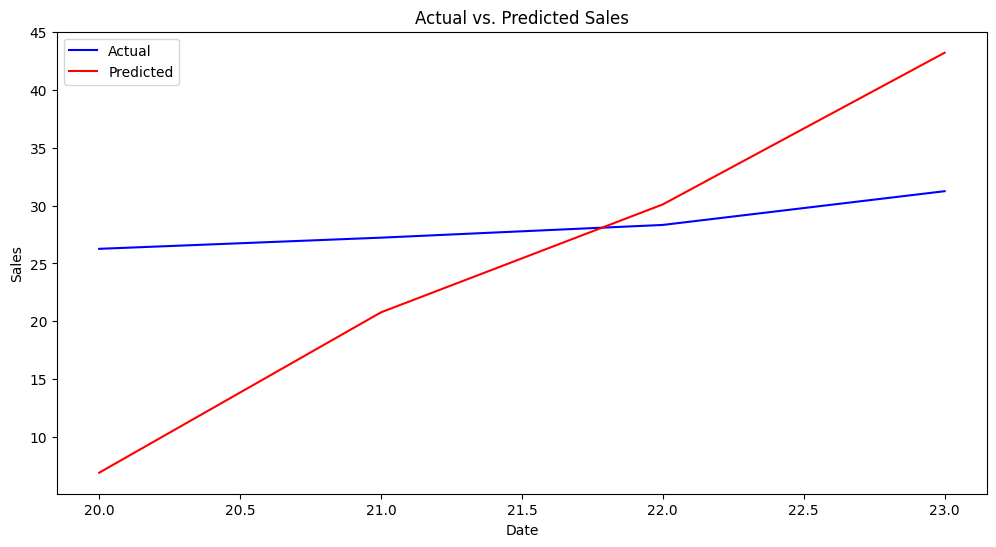

In [ ]:
import matplotlib.pyplot as plt

# Plot actual vs. predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_val.index, y_val, label='Actual', color='blue')
plt.plot(y_val.index, y_pred_lstm, label='Predicted', color='red')
plt.title('Actual vs. Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [ ]:
lstm_df = pd.DataFrame({'Actual': y_val.values.flatten(), 'Predicted': y_pred_lstm.flatten()})

lstm_df

,Actual,Predicted
0,26.262583,6.888443
1,27.229263,20.767595
2,28.330695,30.107031
3,31.250379,43.233006


### Prohpet model

In [ ]:
!pip install prophet

In [ ]:
# Convert X_monthly_resampled to a DataFrame
X_monthly_resampled_df = pd.DataFrame(X_monthly_resampled, index=monthly_sales_transformed_df.index,
                                       columns=['hour', 'day_of_week', 'Campaign', 'Holidays', 'Website_BR',
                                                'FB_Conversion_Rate', 'FB_CPA_transformed', 'FB_ROAS',
                                                'average_order_value_transformed', 'discount_diff',
                                                'FB_CTR_transformed_diff','total_checkouts_transformed_diff' ])


# Join the target variable and features into a single DataFrame
monthly_data = monthly_sales_transformed_df.join(X_monthly_resampled_df)

# Select only the 'date' and 'total_sales' columns
monthly_data_new = monthly_data[['hour', 'day_of_week', 'Campaign', 'Holidays', 'Website_BR',
                                                'FB_Conversion_Rate', 'FB_CPA_transformed', 'FB_ROAS',
                                                'average_order_value_transformed', 'discount_diff',
                                                'FB_CTR_transformed_diff','total_checkouts_transformed_diff',"monthly_sales_transformed"]].copy()

# Rename the columns to 'ds' and 'y' as required by Prophet
monthly_data_new.rename(columns={'hour': 'ds', 'monthly_sales_transformed': 'y'}, inplace=True)

In [ ]:
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


campaigns_2021_2022 = [
    pd.date_range(start='2021-01-19', end='2021-02-08'),
    pd.date_range(start='2021-04-26', end='2021-05-17'),
    pd.date_range(start='2021-06-01', end='2021-07-01'),
    pd.date_range(start='2021-09-01', end='2021-09-15'),
    pd.date_range(start='2021-11-01', end='2021-11-12'),
    pd.date_range(start='2021-12-01', end='2021-12-13'),
    pd.date_range(start='2021-12-13', end='2022-01-02'),
    pd.date_range(start='2022-01-10', end='2022-02-09'),
    pd.date_range(start='2022-03-29', end='2022-04-26'),
    pd.date_range(start='2022-06-01', end='2022-08-01'),
    pd.date_range(start='2022-08-06', end='2022-08-22'),
    pd.date_range(start='2022-08-22', end='2022-10-03'),
    pd.date_range(start='2022-10-03', end='2022-11-01'),
    pd.date_range(start='2022-12-09', end='2023-01-01')
]

# Define holidays date range
holidays_2021_2022 = [
    pd.date_range(start='2021-01-01', end='2021-01-02'),
    pd.date_range(start='2021-01-28', end='2021-01-29'),
    pd.date_range(start='2021-02-01', end='2021-02-02'),
    pd.date_range(start='2021-02-12', end='2021-02-14'),
    pd.date_range(start='2021-04-29', end='2021-05-02'),
    pd.date_range(start='2021-05-09', end='2021-05-10'),
    pd.date_range(start='2021-05-13', end='2021-05-15'),
    pd.date_range(start='2021-05-26', end='2021-05-27'),
    pd.date_range(start='2021-06-07', end='2021-06-08'),
    pd.date_range(start='2021-06-20', end='2021-06-21'),
    pd.date_range(start='2021-07-20', end='2021-07-22'),
    pd.date_range(start='2021-08-10', end='2021-08-11'),
    pd.date_range(start='2021-08-31', end='2021-09-01'),
    pd.date_range(start='2021-09-16', end='2021-09-17'),
    pd.date_range(start='2021-10-19', end='2021-10-20'),
    pd.date_range(start='2021-11-04', end='2021-11-05'),
    pd.date_range(start='2021-11-20', end='2021-11-21'),
    pd.date_range(start='2021-12-03', end='2021-12-04'),
    pd.date_range(start='2021-12-11', end='2021-12-12'),
    pd.date_range(start='2021-12-24', end='2021-12-25'),
    pd.date_range(start='2022-01-01', end='2022-01-02'),
    pd.date_range(start='2022-01-18', end='2022-01-19'),
    pd.date_range(start='2022-02-01', end='2022-02-04'),
    pd.date_range(start='2022-04-19', end='2022-04-20'),
    pd.date_range(start='2022-05-01', end='2022-05-05'),
    pd.date_range(start='2022-05-08', end='2022-05-09'),
    pd.date_range(start='2022-05-15', end='2022-05-17'),
    pd.date_range(start='2022-06-06', end='2022-06-07'),
    pd.date_range(start='2022-06-19', end='2022-06-20'),
    pd.date_range(start='2022-07-10', end='2022-07-12'),
    pd.date_range(start='2022-07-30', end='2022-08-01'),
    pd.date_range(start='2022-08-31', end='2022-09-01'),
    pd.date_range(start='2022-09-16', end='2022-09-17'),
    pd.date_range(start='2022-10-09', end='2022-10-11'),
    pd.date_range(start='2022-10-24', end='2022-10-25'),
    pd.date_range(start='2022-11-18', end='2022-11-21'),
    pd.date_range(start='2022-11-28', end='2022-11-29'),
    pd.date_range(start='2022-12-11', end='2022-12-13'),
    pd.date_range(start='2022-12-25', end='2022-12-27')
]

# Split the data into training and test sets
train_size = int(len(monthly_data_new) * 0.8)  # 80% train, 20% test
train_data, test_data = monthly_data_new[:train_size], monthly_data_new[train_size:]

# Create a Prophet model
model = Prophet(seasonality_mode='additive',
                yearly_seasonality=False,
                weekly_seasonality=False,
                daily_seasonality=False)

# Add campaign regressors
for campaign_dates in campaigns_2021_2022:
    model.add_regressor('Campaign', mode='additive')

# Add regressors
for column in ['Website_BR','FB_Conversion_Rate', 'FB_CPA_transformed', 'FB_ROAS',
                'average_order_value_transformed', 'discount_diff',
               'FB_CTR_transformed_diff']:
    model.add_regressor(column, mode='additive')

# Add Malaysia holidays
for holiday_dates in holidays_2021_2022:
    model.add_country_holidays(country_name='MY')

# Fit the model to the training data
model.fit(train_data)

# Make predictions on the training set
forecast = model.predict(test_data)

# Calculate MAE, MSE, RMSE
y_true = test_data['y'].values
y_pred = forecast['yhat'].values

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


INFO:prophet:n_changepoints greater than number of observations. Using 14.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp1mdxfbxr/u3gn222v.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp1mdxfbxr/9gfsi3se.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=31544', 'data', 'file=/tmp/tmp1mdxfbxr/u3gn222v.json', 'init=/tmp/tmp1mdxfbxr/9gfsi3se.json', 'output', 'file=/tmp/tmp1mdxfbxr/prophet_modeloo9oq703/prophet_model-20240423085735.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
08:57:35 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
08:57:35 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Mean Absolute Error (MAE): 7.26
Mean Squared Error (MSE): 77.17
Root Mean Squared Error (RMSE): 8.78


In [ ]:
# Calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Assuming y_true is your actual values and y_pred is your predicted values
mape_prophet = mean_absolute_percentage_error(y_true, y_pred)

print("Mean Absolute Percentage Error (MAPE): {:.2f}%".format(mape_prophet))


Mean Absolute Percentage Error (MAPE): 25.23%


In [ ]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Awal Muharram (Hijri New Year),Awal Muharram (Hijri New Year)_lower,Awal Muharram (Hijri New Year)_upper,Birthday of SPB Yang di-Pertuan Agong,...,extra_regressors_additive,extra_regressors_additive_lower,extra_regressors_additive_upper,holidays,holidays_lower,holidays_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2022-08-31,22.673220,24.967140,28.981978,22.673214,22.673225,0.0,0.0,0.0,0.0,...,4.142240,4.142240,4.142240,0.087268,0.087268,0.087268,0.0,0.0,0.0,26.902727
1,2022-09-30,22.226509,21.787526,25.826537,22.226493,22.226527,0.0,0.0,0.0,0.0,...,1.593461,1.593461,1.593461,0.000000,0.000000,0.000000,0.0,0.0,0.0,23.819970
2,2022-10-31,21.764909,17.449864,21.654469,21.764876,21.764941,0.0,0.0,0.0,0.0,...,-2.127135,-2.127135,-2.127135,0.000000,0.000000,0.000000,0.0,0.0,0.0,19.637774
3,2022-11-30,21.318199,12.918346,17.018795,21.318146,21.318250,0.0,0.0,0.0,0.0,...,-6.348450,-6.348450,-6.348450,0.000000,0.000000,0.000000,0.0,0.0,0.0,14.969748
4,2022-12-31,20.856598,17.286790,21.303794,20.856524,20.856668,0.0,0.0,0.0,0.0,...,-1.558646,-1.558646,-1.558646,0.000000,0.000000,0.000000,0.0,0.0,0.0,19.297952


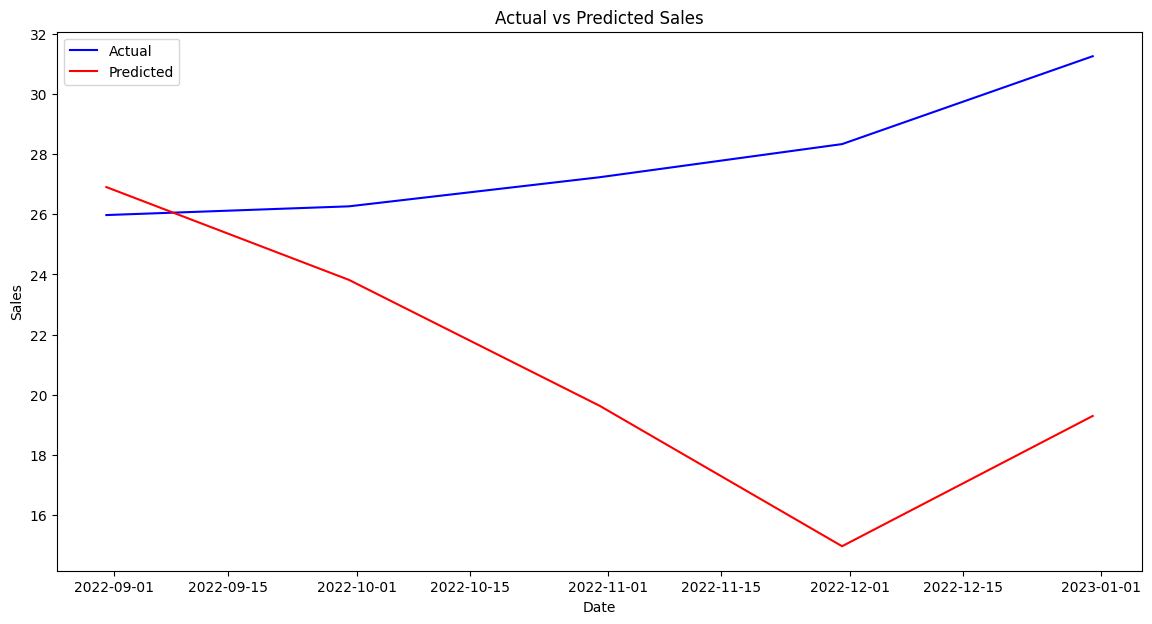

In [ ]:
import matplotlib.pyplot as plt

# Plot actual vs predicted values
plt.figure(figsize=(14, 7))
plt.plot(test_data['ds'], test_data['y'], label='Actual', color='blue')
plt.plot(test_data['ds'], forecast['yhat'], label='Predicted', color='red')
plt.title('Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()



In [ ]:
pro_df = pd.DataFrame({'Actual': test_data['y'].values.flatten(), 'Predicted': forecast['yhat'].values.flatten()})

pro_df

,Actual,Predicted
0,25.973028,26.902727
1,26.262583,23.819970
2,27.229263,19.637774
3,28.330695,14.969748
4,31.250379,19.297952


### XGBoost

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Create XGBoost regressor
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)

# Train the model with early stopping
xgb_reg.fit(X_train_array_m, y_train_array_m,
            eval_set=[(X_train_array_m, y_train_array_m), (X_val_array_m,y_val)],
            early_stopping_rounds=50,
            verbose=False)

# Make predictions
y_pred_xgb = xgb_reg.predict(X_val_array_m)

# Calculate metrics
mae_xgb = mean_absolute_error(y_val, y_pred_xgb)
rmse_xgb = mean_squared_error(y_val, y_pred_xgb, squared=False)

print("Mean Absolute Error:", mae_xgb)
print("Root Mean Squared Error:", rmse_xgb)

# Calculate Mean Absolute Percentage Error (MAPE)
mape_xgb = mean_absolute_percentage_error(y_val, y_pred_xgb)

print(f"Mean Absolute Percentage Error of XGBoost:{mape_xgb:.2f}%")


Mean Absolute Error: 1.6493456359336962
Root Mean Squared Error: 1.7862477516605983
Mean Absolute Percentage Error of XGBoost:8.32%


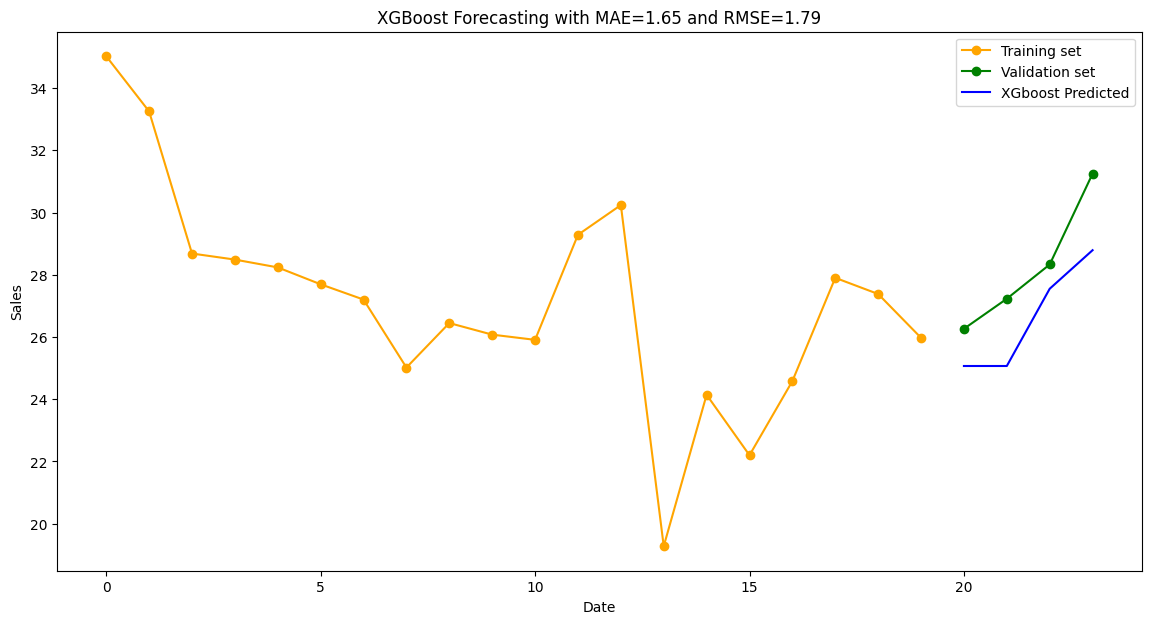

In [ ]:
import matplotlib.pyplot as plt

# Plot actual vs predicted values
plt.figure(figsize=(14, 7))
plt.plot(y_train.index, y_train, label='Training set', color='orange',marker='o')
plt.plot(y_val.index, y_val, label='Validation set', color='green', marker='o')
plt.plot(y_val.index, y_pred_xgb, label='XGboost Predicted', color='blue')
plt.legend()
plt.title(f'XGBoost Forecasting with MAE={mae_xgb:.2f} and RMSE={rmse_xgb:.2f}')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()




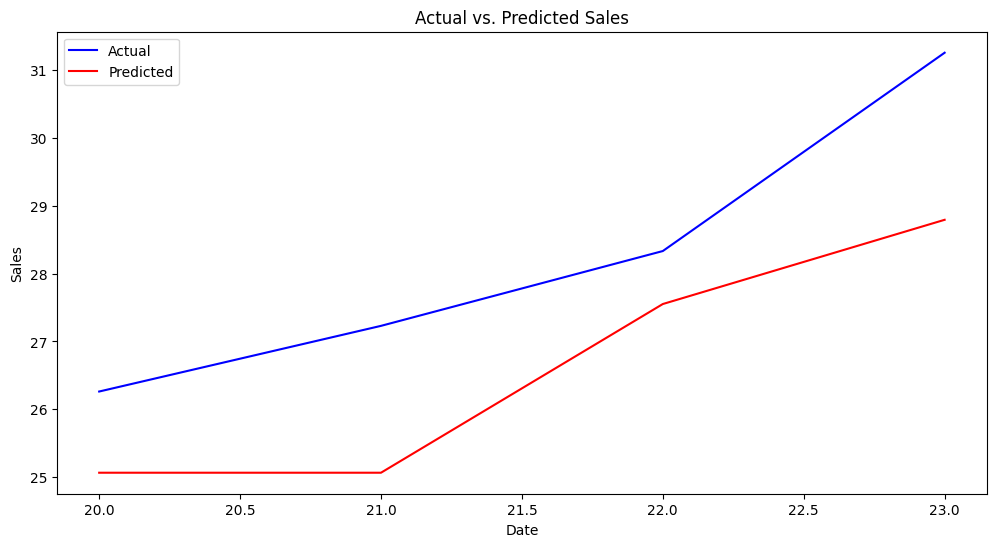

In [ ]:
import matplotlib.pyplot as plt

# Plot actual vs. predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_val.index, y_val, label='Actual', color='blue')
plt.plot(y_val.index, y_pred_xgb, label='Predicted', color='red')
plt.title('Actual vs. Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [ ]:
xgb_df = pd.DataFrame({'Actual': y_val.values.flatten(), 'Predicted': y_pred_xgb.flatten()})

xgb_df

,Actual,Predicted
0,26.262583,25.067133
1,27.229263,25.067133
2,28.330695,27.550632
3,31.250379,28.790640
